# ISTVT: Interpretable Spatial-Temporal Video Transformer for Deepfake Detection

**Based on:** Zhao et al., IEEE TIFS 2023  
**Dataset:** FaceForensics++ Cropped Faces (Kaggle)  

## Pipeline Overview
1. Dataset loading from Kaggle FF++ structure
2. Frame sequence sampling (T=6 consecutive frames)
3. Xception feature extractor (entry flow)
4. Decomposed Spatial-Temporal Self-Attention
5. Self-Subtract Mechanism
6. Training + Evaluation
7. Visualization (LRP-based spatial & temporal heatmaps)

## 0. Setup & Imports

In [2]:
# Install dependencies (run once)
# !pip install timm einops opencv-python-headless matplotlib seaborn scikit-learn -q

In [3]:
import gc
import torch

# Free any leftover memory
gc.collect()
torch.cuda.empty_cache()

# Check available RAM and GPU memory
import psutil
ram = psutil.virtual_memory()
print(f'RAM  : {ram.available/1e9:.1f} GB available / {ram.total/1e9:.1f} GB total')

if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB total')
else:
    print('No GPU — running on CPU only')

RAM  : 32.0 GB available / 33.7 GB total
GPU  : Tesla T4
VRAM : 15.6 GB total


In [4]:
import os
import glob
import random
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import inception_v3

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Dataset Configuration

**Your local dataset structure** (from the screenshots):
```
archive/
├── real/
│   ├── 998_crops/
│   │   ├── frame_0000.png
│   │   ├── frame_0001.png
│   │   └── ...  (20 frames per folder)
│   ├── 999_crops/
│   └── ...
└── fake/
    ├── 000_crops/
    ├── 001_crops/
    └── ...
```
Set `DATA_ROOT` to the full path of your `archive` folder.

In [5]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [6]:
# ── SET THIS TO YOUR LOCAL ARCHIVE FOLDER PATH ───────────────────────────────
DATA_ROOT = '/kaggle/input/datasets/debajyatidey/faceforensics-videos-cropped-faces'   # Windows example
# DATA_ROOT = '/home/yourname/Downloads/archive'       # Linux / Mac example
# ─────────────────────────────────────────────────────────────────────────────

IMG_SIZE             = 128   # paper: 300×300
T_FRAMES             = 4   # paper: T=6 consecutive frames per sequence
BATCH_SIZE           = 2
NUM_EPOCHS           = 10
LR                   = 5e-4  # paper: SGD lr=0.0005
MAX_FRAMES_PER_VIDEO = 20    # your folders have 20 frames each

# Model hyperparameters (paper defaults)
M_BLOCKS = 4   # transformer blocks
N_HEADS  = 4    # attention heads
# ─────────────────────────────────────────────────────────────────────────────

data_root = Path(DATA_ROOT)

# ── Sanity check ─────────────────────────────────────────────────────────────
assert data_root.exists(), (
    f"DATA_ROOT not found: {DATA_ROOT}\n"
    "Please update DATA_ROOT above to the full path of your 'archive' folder."
)

real_dir = data_root / 'real'
fake_dir = data_root / 'fake'

assert real_dir.exists(), f"Expected 'real' subfolder inside {DATA_ROOT}"
assert fake_dir.exists(), f"Expected 'fake' subfolder inside {DATA_ROOT}"

real_vids = sorted([d for d in real_dir.iterdir() if d.is_dir()])
fake_vids = sorted([d for d in fake_dir.iterdir() if d.is_dir()])

print(f"DATA_ROOT  : {data_root}")
print(f"real/      : {len(real_vids)} video folders  (e.g. {real_vids[0].name if real_vids else 'none'})")
print(f"fake/      : {len(fake_vids)} video folders  (e.g. {fake_vids[0].name if fake_vids else 'none'})")

# Peek inside first real folder
if real_vids:
    sample_frames = sorted(real_vids[0].glob('*.png')) + sorted(real_vids[0].glob('*.jpg'))
    print(f"\nSample folder : {real_vids[0].name}")
    print(f"  Frames found: {len(sample_frames)}")
    print(f"  First frame : {sample_frames[0].name if sample_frames else 'none'}")
    print(f"  Last  frame : {sample_frames[-1].name if sample_frames else 'none'}")


DATA_ROOT  : /kaggle/input/datasets/debajyatidey/faceforensics-videos-cropped-faces
real/      : 1000 video folders  (e.g. 000_crops)
fake/      : 1000 video folders  (e.g. 000_003_crops)

Sample folder : 000_crops
  Frames found: 20
  First frame : frame_0000.png
  Last  frame : frame_0019.png


In [7]:
def discover_sequences(data_root, t_frames=6, max_frames=20):
    """
    Scans archive/real/ and archive/fake/ and builds a list of
    (frame_paths, label) tuples matched to your local structure:

        archive/real/<NNN_crops>/frame_0000.png ... frame_0019.png  → label 0
        archive/fake/<NNN_crops>/frame_0000.png ... frame_0019.png  → label 1

    Each folder has ~20 frames, so with T_FRAMES=6 we get 3 non-overlapping
    sequences of 6 frames per video folder (frames 0-5, 6-11, 12-17).
    """
    sequences = []  # [(list_of_frame_paths, label), ...]

    def _add_video_dir(video_dir: Path, label: int):
        """Slice one video folder into non-overlapping t_frames-length sequences."""
        frames = sorted(
            list(video_dir.glob('*.png')) + list(video_dir.glob('*.jpg'))
        )
        frames = frames[:max_frames]  # cap (20 in your dataset)

        if len(frames) < t_frames:
            # Folder has fewer frames than needed — skip with a warning
            print(f"  [SKIP] {video_dir.name}: only {len(frames)} frames (need {t_frames})")
            return

        # Non-overlapping windows
        for start in range(0, len(frames) - t_frames + 1, t_frames):
            seq = frames[start : start + t_frames]
            sequences.append(([str(f) for f in seq], label))

    real_dir = data_root / 'real'
    fake_dir = data_root / 'fake'

    # ── Real videos (label = 0) ──────────────────────────────────────────────
    real_dirs = sorted([d for d in real_dir.iterdir() if d.is_dir()])
    print(f"Scanning {len(real_dirs)} real video folders...")
    for vdir in real_dirs:
        _add_video_dir(vdir, label=0)

    # ── Fake videos (label = 1) ──────────────────────────────────────────────
    fake_dirs = sorted([d for d in fake_dir.iterdir() if d.is_dir()])
    print(f"Scanning {len(fake_dirs)} fake video folders...")
    for vdir in fake_dirs:
        _add_video_dir(vdir, label=1)

    n_real = sum(1 for _, l in sequences if l == 0)
    n_fake = sum(1 for _, l in sequences if l == 1)
    print(f"\nTotal sequences : {len(sequences)}")
    print(f"  Real (label=0): {n_real}")
    print(f"  Fake (label=1): {n_fake}")

    if len(sequences) == 0:
        raise RuntimeError(
            "No sequences found! Check that:\n"
            "  1. DATA_ROOT points to the 'archive' folder\n"
            "  2. archive/real/ and archive/fake/ exist\n"
            "  3. Each subfolder contains .png or .jpg files"
        )
    return sequences


all_sequences = discover_sequences(data_root, T_FRAMES, MAX_FRAMES_PER_VIDEO)

# ── Preview first sequence ────────────────────────────────────────────────────
paths0, label0 = all_sequences[0]
print(f"\nFirst sequence preview (label={'REAL' if label0==0 else 'FAKE'}):")
for p in paths0:
    print(f"  {p}")


Scanning 1000 real video folders...
Scanning 1000 fake video folders...

Total sequences : 9980
  Real (label=0): 4996
  Fake (label=1): 4984

First sequence preview (label=REAL):
  /kaggle/input/datasets/debajyatidey/faceforensics-videos-cropped-faces/real/000_crops/frame_0000.png
  /kaggle/input/datasets/debajyatidey/faceforensics-videos-cropped-faces/real/000_crops/frame_0001.png
  /kaggle/input/datasets/debajyatidey/faceforensics-videos-cropped-faces/real/000_crops/frame_0002.png
  /kaggle/input/datasets/debajyatidey/faceforensics-videos-cropped-faces/real/000_crops/frame_0003.png


## 2. Dataset & DataLoader

In [8]:
class FF_SequenceDataset(Dataset):
    """
    Returns a tensor of shape (T, C, H, W) for each sequence.
    """
    def __init__(self, sequences, img_size=300, augment=False):
        self.sequences = sequences
        self.img_size  = img_size
        self.augment   = augment

        base_tf = [
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ]
        aug_tf = [
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
        ]
        from torchvision.transforms import Compose
        self.transform = Compose(aug_tf if augment else base_tf)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        frames = []
        for fp in frame_paths:
            img = cv2.imread(fp)
            if img is None:
                img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            from PIL import Image
            img = Image.fromarray(img)
            frames.append(self.transform(img))  # (C,H,W)
        frames_tensor = torch.stack(frames, dim=0)  # (T,C,H,W)
        return frames_tensor, torch.tensor(label, dtype=torch.long)


# Train / Val / Test split  (70 / 15 / 15)
random.shuffle(all_sequences)
n = len(all_sequences)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_seq = all_sequences[:n_train]
val_seq   = all_sequences[n_train:n_train + n_val]
test_seq  = all_sequences[n_train + n_val:]
print(f'Train: {len(train_seq)} | Val: {len(val_seq)} | Test: {len(test_seq)}')

train_ds = FF_SequenceDataset(train_seq, IMG_SIZE, augment=True)
val_ds   = FF_SequenceDataset(val_seq,   IMG_SIZE, augment=False)
test_ds  = FF_SequenceDataset(test_seq,  IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Quick sanity check
x, y = next(iter(train_loader))
print(f'Batch shape: {x.shape}  Labels: {y}')

Train: 6986 | Val: 1497 | Test: 1497
Batch shape: torch.Size([2, 4, 3, 128, 128])  Labels: tensor([0, 0])


## 3. Xception Feature Extractor (Entry Flow)
Paper: entry flow of Xception → 19×19×728 feature map for 300×300 input

In [9]:
class SeparableConv2d(nn.Module):
    """Depthwise-separable convolution (core Xception building block)."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel, stride, padding, groups=in_ch, bias=bias)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=bias)

    def forward(self, x):
        return self.pw(self.dw(x))


class XceptionBlock(nn.Module):
    """Residual separable-conv block used in Xception entry flow."""
    def __init__(self, in_ch, out_ch, reps, stride=1, start_with_relu=True, grow_first=True):
        super().__init__()
        # Shortcut
        if out_ch != in_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.skip = None

        layers = []
        ch = in_ch
        for i in range(reps):
            is_last = (i == reps - 1)
            out = out_ch if (grow_first or is_last) else in_ch
            if start_with_relu or i > 0:
                layers.append(nn.ReLU(inplace=True))
            layers.append(SeparableConv2d(ch, out))
            layers.append(nn.BatchNorm2d(out))
            ch = out
        if stride != 1:
            layers.append(nn.MaxPool2d(3, stride=stride, padding=1))
        self.rep = nn.Sequential(*layers)

    def forward(self, x):
        out = self.rep(x)
        skip = self.skip(x) if self.skip else x
        return out + skip


class XceptionEntryFlow(nn.Module):
    """
    Xception Entry Flow.
    Input : (B, 3, 300, 300)
    Output: (B, 728, 19, 19)   → matches paper dimensions
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(64)

        self.block1 = XceptionBlock(64,  128, reps=2, stride=2, start_with_relu=False)
        self.block2 = XceptionBlock(128, 256, reps=2, stride=2, start_with_relu=True)
        self.block3 = XceptionBlock(256, 728, reps=2, stride=2, start_with_relu=True)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x  # (B, 728, 19, 19)


# Verify output shape
feat_ex = XceptionEntryFlow()
dummy = torch.randn(2, 3, 300, 300)
out = feat_ex(dummy)
print('Xception entry flow output:', out.shape)  # expect (2, 728, 19, 19)

Xception entry flow output: torch.Size([2, 728, 19, 19])


## 4. Decomposed Spatial-Temporal Self-Attention

**Temporal SA** (Eq. 1): attention along T dimension at each spatial position j  
**Spatial SA** (Eq. 2): attention along HW dimension at each temporal position k  
Complexity reduced from O(T²H²W²) → O(T² + H²W²)

In [10]:
class TemporalSelfAttention(nn.Module):
    """
    Temporal self-attention (Eq. 1 in paper).
    For each spatial position j, attends over T temporal tokens.
    Input:  (T+1, HW+1, N, D)
    Output: same shape
    """
    def __init__(self, n_heads, d_head, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head  = d_head
        self.scale   = d_head ** -0.5
        self.dropout = nn.Dropout(dropout)
        # Store attention maps for visualization
        self.attn_map = None

    def forward(self, q, k, v):
        """
        q, k, v: (T+1, HW+1, N, D)  →  rearranged to (N*(HW+1), T+1, D)
        """
        T1, S1, N, D = q.shape   # T1=T+1, S1=HW+1
        # Rearrange: treat each spatial position independently
        q = q.permute(2, 1, 0, 3).reshape(N * S1, T1, D)  # (N*S1, T1, D)
        k = k.permute(2, 1, 0, 3).reshape(N * S1, T1, D)
        v = v.permute(2, 1, 0, 3).reshape(N * S1, T1, D)

        attn = torch.bmm(q, k.transpose(-1, -2)) * self.scale  # (N*S1, T1, T1)
        attn = F.softmax(attn, dim=-1)
        self.attn_map = attn.detach()   # save for LRP visualization
        attn = self.dropout(attn)

        out = torch.bmm(attn, v)        # (N*S1, T1, D)
        out = out.reshape(N, S1, T1, D).permute(2, 1, 0, 3)  # back to (T1, S1, N, D)
        return out


class SpatialSelfAttention(nn.Module):
    """
    Spatial self-attention (Eq. 2 in paper).
    For each temporal position k, attends over HW spatial tokens.
    """
    def __init__(self, n_heads, d_head, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head  = d_head
        self.scale   = d_head ** -0.5
        self.dropout = nn.Dropout(dropout)
        self.attn_map = None

    def forward(self, q, k, v):
        """
        q, k, v: (T+1, HW+1, N, D)  →  rearranged to (N*(T+1), HW+1, D)
        """
        T1, S1, N, D = q.shape
        q = q.permute(2, 0, 1, 3).reshape(N * T1, S1, D)   # (N*T1, S1, D)
        k = k.permute(2, 0, 1, 3).reshape(N * T1, S1, D)
        v = v.permute(2, 0, 1, 3).reshape(N * T1, S1, D)

        attn = torch.bmm(q, k.transpose(-1, -2)) * self.scale  # (N*T1, S1, S1)
        attn = F.softmax(attn, dim=-1)
        self.attn_map = attn.detach()
        attn = self.dropout(attn)

        out = torch.bmm(attn, v)          # (N*T1, S1, D)
        out = out.reshape(N, T1, S1, D).permute(1, 2, 0, 3)  # (T1, S1, N, D)
        return out


print('Attention modules defined.')

Attention modules defined.


## 5. Self-Subtract Mechanism (Eq. 3)

Subtracts adjacent temporal tokens so the network focuses on **inter-frame inconsistency**:  
`I' = cat([I[0:2], I[2:] - I[1:-1]], dim=0)`

In [11]:
def self_subtract(x):
    """
    Self-subtract mechanism (Eq. 3).
    x: (T+1, HW+1, C)  — first dim is temporal (0=cls token, 1..T=frame tokens)
    Returns x' of same shape where frame tokens[i] = frame_tokens[i] - frame_tokens[i-1]
    """
    # x[0:2] keeps cls token (index 0) and first frame token (index 1)
    # x[2:]  - x[1:-1]  computes adjacent differences for the rest
    cls_and_first = x[0:2]                         # (2, HW+1, C)
    diff          = x[2:] - x[1:-1]               # (T-1, HW+1, C)
    return torch.cat([cls_and_first, diff], dim=0) # (T+1, HW+1, C)


# Quick shape test
test_t = torch.randn(7, 362, 64)  # T+1=7, HW+1=362 (19*19+1), C=64
print('Self-subtract output:', self_subtract(test_t).shape)  # should be (7, 362, 64)

Self-subtract output: torch.Size([7, 362, 64])


## 6. Decomposed Spatial-Temporal Transformer Block

In [12]:
class DecomposedSTBlock(nn.Module):
    """
    One Spatial-Temporal Transformer Block (Fig. 2 in paper).
    Order: Temporal SA (with self-subtract on Q,K) → Spatial SA → FFN
    Each sub-layer wrapped in residual + LayerNorm.
    """
    def __init__(self, embed_dim, n_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        assert embed_dim % n_heads == 0
        d_head = embed_dim // n_heads

        # Temporal branch
        self.norm_t  = nn.LayerNorm(embed_dim)
        self.proj_qt = nn.Linear(embed_dim, embed_dim, bias=False)
        self.proj_kt = nn.Linear(embed_dim, embed_dim, bias=False)
        self.proj_vt = nn.Linear(embed_dim, embed_dim, bias=False)
        self.temp_sa = TemporalSelfAttention(n_heads, d_head, dropout)
        self.out_t   = nn.Linear(embed_dim, embed_dim)

        # Spatial branch
        self.norm_s  = nn.LayerNorm(embed_dim)
        self.proj_qs = nn.Linear(embed_dim, embed_dim, bias=False)
        self.proj_ks = nn.Linear(embed_dim, embed_dim, bias=False)
        self.proj_vs = nn.Linear(embed_dim, embed_dim, bias=False)
        self.spat_sa = SpatialSelfAttention(n_heads, d_head, dropout)
        self.out_s   = nn.Linear(embed_dim, embed_dim)

        # Feed-forward network
        hidden = int(embed_dim * mlp_ratio)
        self.norm_ff = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def _split_heads(self, x, n_heads, d_head):
        """(T1, S1, C) → (T1, S1, N, D)"""
        T1, S1, C = x.shape
        return x.reshape(T1, S1, n_heads, d_head)

    def _merge_heads(self, x):
        """(T1, S1, N, D) → (T1, S1, N*D)"""
        T1, S1, N, D = x.shape
        return x.reshape(T1, S1, N * D)

    def forward(self, x):
        """
        x: (T+1, HW+1, C)
        """
        N_heads  = self.temp_sa.n_heads
        D_head   = self.temp_sa.d_head
        C        = N_heads * D_head

        # ── Temporal Self-Attention ──────────────────────────────────────────
        res = x
        x_  = self.norm_t(x)

        # Self-subtract applied to Q, K only (V stays original)
        x_sub = self_subtract(x_)
        Q = self._split_heads(self.proj_qt(x_sub), N_heads, D_head)
        K = self._split_heads(self.proj_kt(x_sub), N_heads, D_head)
        V = self._split_heads(self.proj_vt(x_),    N_heads, D_head)

        t_out = self.temp_sa(Q, K, V)          # (T+1, HW+1, N, D)
        t_out = self.out_t(self._merge_heads(t_out))
        x = res + t_out

        # ── Spatial Self-Attention ───────────────────────────────────────────
        res = x
        x_  = self.norm_s(x)
        Q = self._split_heads(self.proj_qs(x_), N_heads, D_head)
        K = self._split_heads(self.proj_ks(x_), N_heads, D_head)
        V = self._split_heads(self.proj_vs(x_), N_heads, D_head)

        s_out = self.spat_sa(Q, K, V)          # (T+1, HW+1, N, D)
        s_out = self.out_s(self._merge_heads(s_out))
        x = res + s_out

        # ── Feed-Forward Network ─────────────────────────────────────────────
        x = x + self.ffn(self.norm_ff(x))
        return x


print('DecomposedSTBlock defined.')

DecomposedSTBlock defined.


## 7. Full ISTVT Model

In [13]:
class ISTVT(nn.Module):
    """
    Interpretable Spatial-Temporal Video Transformer (Fig. 2).

    Architecture:
      1. Xception Entry Flow  → (B*T, 728, H, W)
      2. Flatten patches      → tokens (T, HW, 728)
      3. Concat cls tokens (spatial + temporal) + pos embedding
      4. M × DecomposedSTBlock
      5. MLP prediction head on O[0, 0, :]
    """
    def __init__(self,
                 t_frames  = 6,
                 feat_h    = 19,
                 feat_w    = 19,
                 embed_dim = 728,
                 n_heads   = 8,
                 m_blocks  = 12,
                 n_classes = 2,
                 dropout   = 0.1):
        super().__init__()
        self.T          = t_frames
        self.H          = feat_h
        self.W          = feat_w
        self.HW         = feat_h * feat_w   # 361
        self.embed_dim  = embed_dim

        # Feature extractor
        self.feat_extractor = XceptionEntryFlow()

        # Classification tokens
        # Spatial cls: one per temporal position  → (T, 1, C)
        self.spatial_cls  = nn.Parameter(torch.zeros(t_frames, 1, embed_dim))
        # Temporal cls: one for the whole sequence → (1, HW+1, C)
        self.temporal_cls = nn.Parameter(torch.zeros(1, feat_h * feat_w + 1, embed_dim))

        # Learnable position embedding for (T+1) × (HW+1) tokens
        self.pos_embed = nn.Parameter(
            torch.zeros(t_frames + 1, feat_h * feat_w + 1, embed_dim)
        )
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.spatial_cls, std=0.02)
        nn.init.trunc_normal_(self.temporal_cls, std=0.02)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            DecomposedSTBlock(embed_dim, n_heads, dropout=dropout)
            for _ in range(m_blocks)
        ])

        # Prediction head
        self.norm_head = nn.LayerNorm(embed_dim)
        self.head      = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)
        )

    def extract_features(self, x):
        """
        x: (B, T, 3, Hi, Wi)
        Returns feature maps: (B, T, C, H, W)
        """
        B, T, C, Hi, Wi = x.shape
        x = x.reshape(B * T, C, Hi, Wi)
        f = self.feat_extractor(x)       # (B*T, 728, 19, 19)
        f = f.reshape(B, T, self.embed_dim, self.H, self.W)
        return f

    def forward(self, x):
        """
        x: (B, T, 3, Hi, Wi)
        Returns logits: (B, 2)
        """
        B = x.shape[0]

        # --- Feature extraction ---
        f = self.extract_features(x)        # (B, T, C, H, W)

        # --- Tokenize: flatten spatial dims ---
        # (B, T, C, H, W) → (B, T, HW, C)
        f = f.reshape(B, self.T, self.embed_dim, self.HW)
        f = f.permute(0, 1, 3, 2)           # (B, T, HW, C)

        # --- Concatenate spatial classification tokens ---
        sp_cls = self.spatial_cls.unsqueeze(0).expand(B, -1, -1, -1)  # (B,T,1,C)
        tokens = torch.cat([sp_cls, f], dim=2)   # (B, T, HW+1, C)

        # --- Concatenate temporal classification tokens ---
        t_cls = self.temporal_cls.unsqueeze(0).expand(B, -1, -1, -1)  # (B,1,HW+1,C)
        tokens = torch.cat([t_cls, tokens], dim=1)  # (B, T+1, HW+1, C)

        # --- Add positional embedding ---
        tokens = tokens + self.pos_embed.unsqueeze(0)  # broadcast over B

        # --- Transformer blocks (process each sample independently) ---
        # Reshape: treat batch dim inside; blocks work on (T+1, HW+1, C)
        # For simplicity process each sample; for speed could batch differently
        outs = []
        for b in range(B):
            tok = tokens[b]             # (T+1, HW+1, C)
            for blk in self.blocks:
                tok = blk(tok)
            outs.append(tok)
        tokens = torch.stack(outs, dim=0)   # (B, T+1, HW+1, C)

        # --- Prediction: use O[0, 0, :] (temporal cls at spatial cls position) ---
        cls_token = tokens[:, 0, 0, :]     # (B, C)
        cls_token = self.norm_head(cls_token)
        logits = self.head(cls_token)       # (B, 2)
        return logits


# Instantiate and verify
# ── Auto-calculate correct feature map size ───────────────────────────────
import torch

# Run a dummy input through Xception to get actual output size
feat_ex_test = XceptionEntryFlow().to(DEVICE)
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    feat_out = feat_ex_test(dummy)
    FEAT_H = feat_out.shape[2]
    FEAT_W = feat_out.shape[3]
    EMBED_DIM = feat_out.shape[1]
del feat_ex_test, dummy, feat_out
torch.cuda.empty_cache()

print(f'IMG_SIZE  : {IMG_SIZE}')
print(f'FEAT_H    : {FEAT_H}')
print(f'FEAT_W    : {FEAT_W}')
print(f'EMBED_DIM : {EMBED_DIM}')

# ── Build model with correct dimensions ───────────────────────────────────
model = ISTVT(
    t_frames  = T_FRAMES,
    feat_h    = FEAT_H,       # auto-calculated
    feat_w    = FEAT_W,       # auto-calculated
    embed_dim = EMBED_DIM,    # auto-calculated
    n_heads   = N_HEADS,
    m_blocks  = M_BLOCKS,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params/1e6:.1f}M')

# Forward pass check
with torch.no_grad():
    dummy_in  = torch.randn(1, T_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_out = model(dummy_in)
    print(f'Output shape: {dummy_out.shape}')  # expect (1, 2)

IMG_SIZE  : 128
FEAT_H    : 8
FEAT_W    : 8
EMBED_DIM : 728

Total trainable parameters: 35.5M
Output shape: torch.Size([1, 2])


## 8. Training

In [14]:
criterion = nn.CrossEntropyLoss()

# Paper: SGD optimizer, lr=0.0005, warm-up scheduler
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)

def get_lr_scheduler(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS):
    """Linear warm-up then cosine decay."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_lr_scheduler(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS)


def run_epoch(loader, model, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0., 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * y.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    return total_loss / total, 100. * correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc, best_epoch = 0., 0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   model, train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc, best_epoch = vl_acc, epoch
        torch.save(model.state_dict(), 'best_istvt.pth')

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}% | '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%  '
          f'[best={best_val_acc:.2f}% @ ep{best_epoch}]')

print('\nTraining complete.')

  0%|          | 0/3493 [00:00<?, ?it/s]

  0%|          | 0/749 [00:00<?, ?it/s]

Epoch   1/10 | Train Loss: 0.6907  Acc: 55.81% | Val Loss: 0.6707  Acc: 59.72%  [best=59.72% @ ep1]


  0%|          | 0/3493 [00:00<?, ?it/s]

  0%|          | 0/749 [00:00<?, ?it/s]

...

  0%|          | 0/749 [00:00<?, ?it/s]

Epoch   9/10 | Train Loss: 0.6002  Acc: 86.72% | Val Loss: 0.6568  Acc: 85.50%  [best=85.50% @ ep9]


  0%|          | 0/3493 [00:00<?, ?it/s]

  0%|          | 0/749 [00:00<?, ?it/s]

Epoch  10/10 | Train Loss: 0.5634  Acc: 87.53% | Val Loss: 0.6377  Acc: 86.04%  [best=86.04% @ ep10]

Training complete.


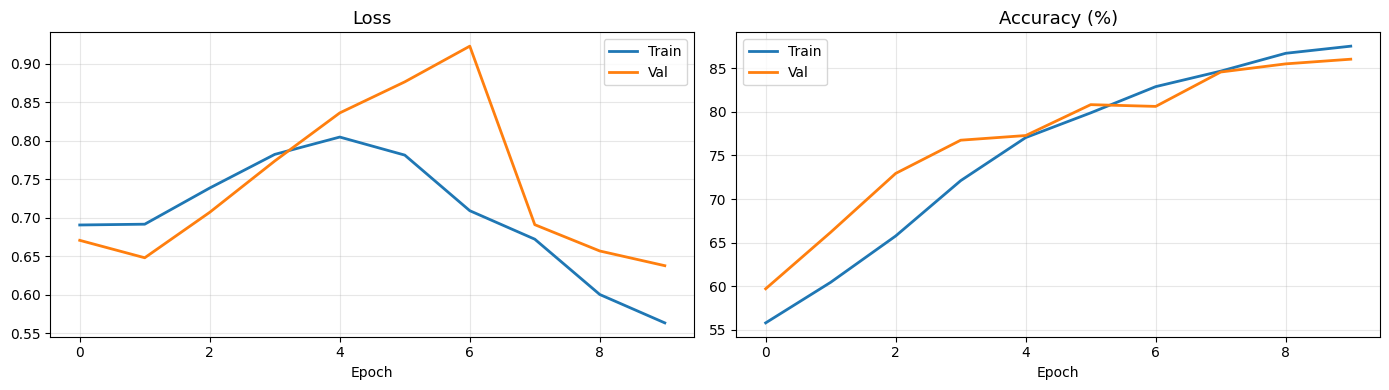

In [15]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=2)
axes[1].set_title('Accuracy (%)', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 9. Test Evaluation

  0%|          | 0/749 [00:00<?, ?it/s]

Test Accuracy : 85.84%
Test AUROC    : 93.14%

               precision    recall  f1-score   support

        Real       0.89      0.82      0.85       755
        Fake       0.83      0.90      0.86       742

    accuracy                           0.86      1497
   macro avg       0.86      0.86      0.86      1497
weighted avg       0.86      0.86      0.86      1497



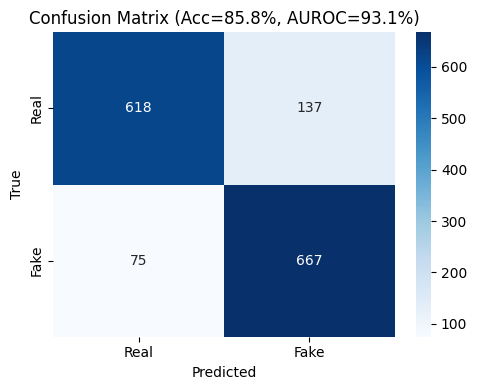

In [16]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns

# Load best checkpoint
model.load_state_dict(torch.load('best_istvt.pth', map_location=DEVICE))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(DEVICE)
        logits = model(x)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()  # P(fake)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_labels.extend(y.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

acc  = accuracy_score(all_labels, all_preds) * 100
auroc = roc_auc_score(all_labels, all_probs) * 100
print(f'Test Accuracy : {acc:.2f}%')
print(f'Test AUROC    : {auroc:.2f}%')
print('\n', classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title(f'Confusion Matrix (Acc={acc:.1f}%, AUROC={auroc:.1f}%)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 10. Visualization: LRP-based Spatial & Temporal Heatmaps

Implements **Algorithm 1** from the paper.  
For each transformer block m:  
- Compute relevance via `Ā = I + max(E_h[R ∘ ∇A], 0)`  
- Accumulate via matrix multiplication across all M blocks

In [17]:
class ISTVTVisualizer:
    """
    Implements Algorithm 1 from the paper.
    Produces separate spatial and temporal heatmaps per frame.
    """
    def __init__(self, model: ISTVT):
        self.model = model
        self.model.eval()
        self.grad_t = {}   # gradients of temporal attention maps
        self.grad_s = {}   # gradients of spatial attention maps
        self.rel_t  = {}   # relevance of temporal attention maps
        self.rel_s  = {}   # relevance of spatial attention maps
        self._hooks = []

    def _register_hooks(self):
        self._remove_hooks()
        for m_idx, blk in enumerate(self.model.blocks):
            # Temporal attention gradient hook
            def make_grad_hook_t(idx):
                def hook(grad):
                    self.grad_t[idx] = grad
                return hook

            def make_grad_hook_s(idx):
                def hook(grad):
                    self.grad_s[idx] = grad
                return hook

            # Forward hook to capture attention + register grad hook
            def make_fwd_hook_t(idx, blk_ref):
                def hook(module, inp, out):
                    attn = blk_ref.temp_sa.attn_map   # (N*S1, T1, T1)
                    if attn is not None:
                        attn = attn.clone().requires_grad_(True)
                        self.rel_t[idx] = attn
                        attn.register_hook(make_grad_hook_t(idx))
                return hook

            def make_fwd_hook_s(idx, blk_ref):
                def hook(module, inp, out):
                    attn = blk_ref.spat_sa.attn_map
                    if attn is not None:
                        attn = attn.clone().requires_grad_(True)
                        self.rel_s[idx] = attn
                        attn.register_hook(make_grad_hook_s(idx))
                return hook

            h1 = blk.register_forward_hook(make_fwd_hook_t(m_idx, blk))
            h2 = blk.register_forward_hook(make_fwd_hook_s(m_idx, blk))
            self._hooks.extend([h1, h2])

    def _remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

    @staticmethod
    def _compute_A_bar(R, grad_A):
        """
        Eq. 4:  Ā = I + max( E_h[R ∘ ∇A], 0 )
        R, grad_A: (N*S1_or_T1, T1_or_S1, T1_or_S1)
        Returns: attention-weighted relevance matrix, same spatial dim.
        """
        elem = R * grad_A               # Hadamard product
        # Mean over head dimension (first dim here flattened as N*spatial)
        # We need to reshape: can only approximate E_h as mean
        Eh = elem.mean(0)               # average over (N*spatial), → (T1, T1)
        A_bar = torch.eye(Eh.shape[-1], device=Eh.device) + F.relu(Eh)
        return A_bar

    def generate_heatmaps(self, x):
        """
        x: (1, T, 3, Hi, Wi)  — single sample
        Returns:
          Ut: (T, Hi, Wi)  temporal heatmap per frame
          Us: (T, Hi, Wi)  spatial heatmap per frame
        """
        assert x.shape[0] == 1, 'Visualizer operates on one sample at a time'
        self.grad_t.clear(); self.grad_s.clear()
        self.rel_t.clear();  self.rel_s.clear()

        x = x.to(DEVICE).requires_grad_(False)
        M   = len(self.model.blocks)
        T   = self.model.T
        H, W = self.model.H, self.model.W
        HW  = H * W
        Hi, Wi = x.shape[3], x.shape[4]

        # Forward pass with gradient tracking
        logits = self.model(x)                   # (1, 2)
        # Backward for class 1 (Fake class, index 1 per paper)
        self.model.zero_grad()
        logits[0, 1].backward()

        # Initialize U matrices (Algorithm 1 lines 4, 8-9, 12-13)
        Ut = torch.eye(T + 1, device=DEVICE)   # accumulator for temporal
        Us = torch.eye(HW + 1, device=DEVICE)  # accumulator for spatial

        for m in range(M):
            # --- Temporal ---
            if m in self.rel_t and m in self.grad_t:
                R_t  = self.rel_t[m]             # (N*S1, T1, T1)
                gA_t = self.grad_t[m]
                if gA_t is not None:
                    A_bar_t = self._compute_A_bar(R_t, gA_t)  # (T1, T1)
                    # Normalize rows
                    A_bar_t = A_bar_t / (A_bar_t.sum(dim=-1, keepdim=True) + 1e-8)
                    Ut = Ut @ A_bar_t             # Eq. 5

            # --- Spatial ---
            if m in self.rel_s and m in self.grad_s:
                R_s  = self.rel_s[m]
                gA_s = self.grad_s[m]
                if gA_s is not None:
                    A_bar_s = self._compute_A_bar(R_s, gA_s)  # (S1, S1)
                    A_bar_s = A_bar_s / (A_bar_s.sum(dim=-1, keepdim=True) + 1e-8)
                    Us = Us @ A_bar_s

        # --- Extract CLS token relevance (Algorithm 1 line 16) ---
        # Ut shape: (T+1, T+1) → row 0 = relevance from temporal cls to each frame
        ut_vec = Ut[0, 1:]   # (T,)  exclude cls-to-cls
        us_vec = Us[0, 1:]   # (HW,) exclude cls-to-cls

        # --- Rearrange & upscale (Algorithm 1 lines 17-18) ---
        # Temporal: broadcast relevance over spatial dims
        Ut_map = ut_vec.unsqueeze(-1).unsqueeze(-1).expand(T, H, W)  # (T, H, W)

        # Spatial: reshape to (H, W) and broadcast over frames
        us_2d  = us_vec.reshape(H, W)            # (H, W)
        Us_map = us_2d.unsqueeze(0).expand(T, -1, -1)  # (T, H, W)

        # Upscale to original image size
        def upscale(hmap):
            hmap = hmap.unsqueeze(0).unsqueeze(0).float()  # (1, 1, T, H, W)
            hmap = F.interpolate(
                hmap.reshape(1, T, H, W).unsqueeze(0),
                size=(T, Hi, Wi), mode='trilinear', align_corners=False
            ).squeeze()
            return hmap.detach().cpu().numpy()  # (T, Hi, Wi)

        Ut_up = upscale(Ut_map)
        Us_up = upscale(Us_map)
        return Ut_up, Us_up


visualizer = ISTVTVisualizer(model)
print('Visualizer ready.')

Visualizer ready.


Visualizing FAKE sequence...


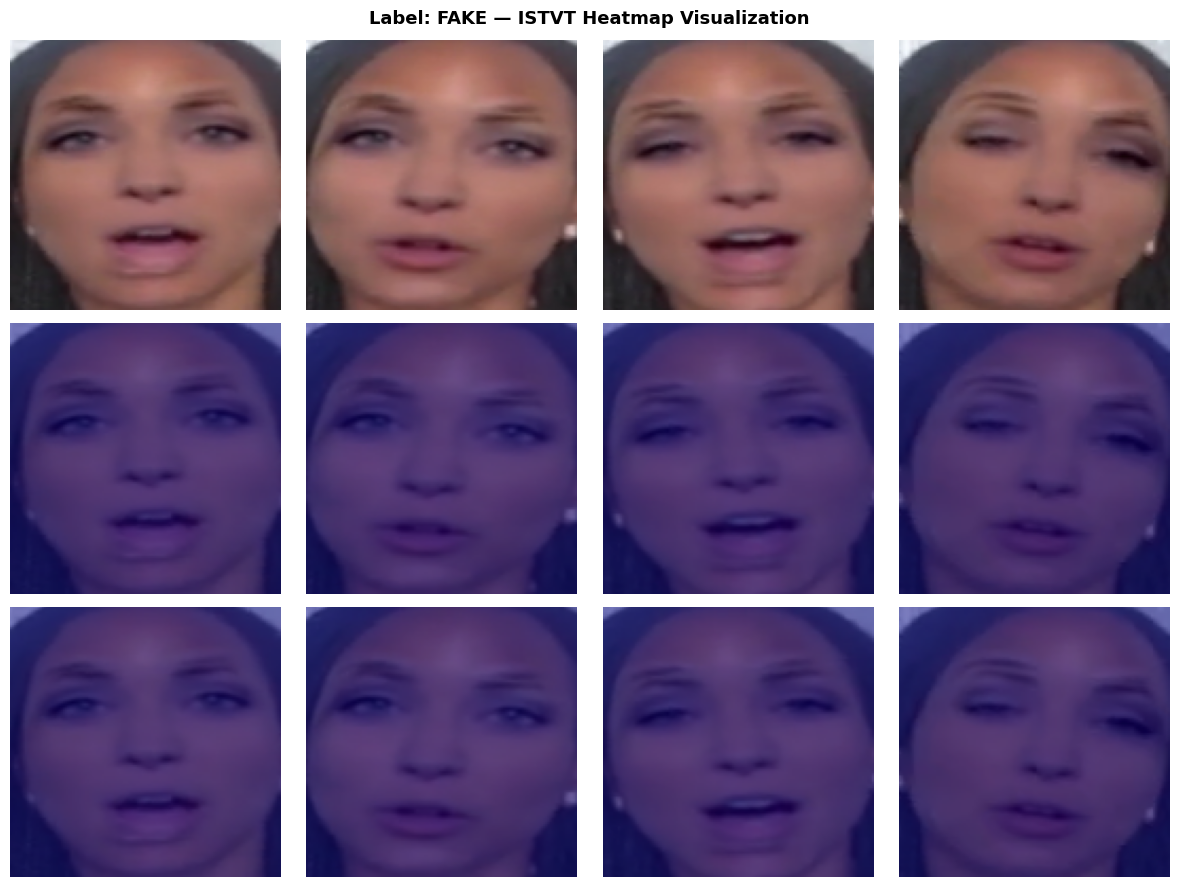

Visualizing REAL sequence...


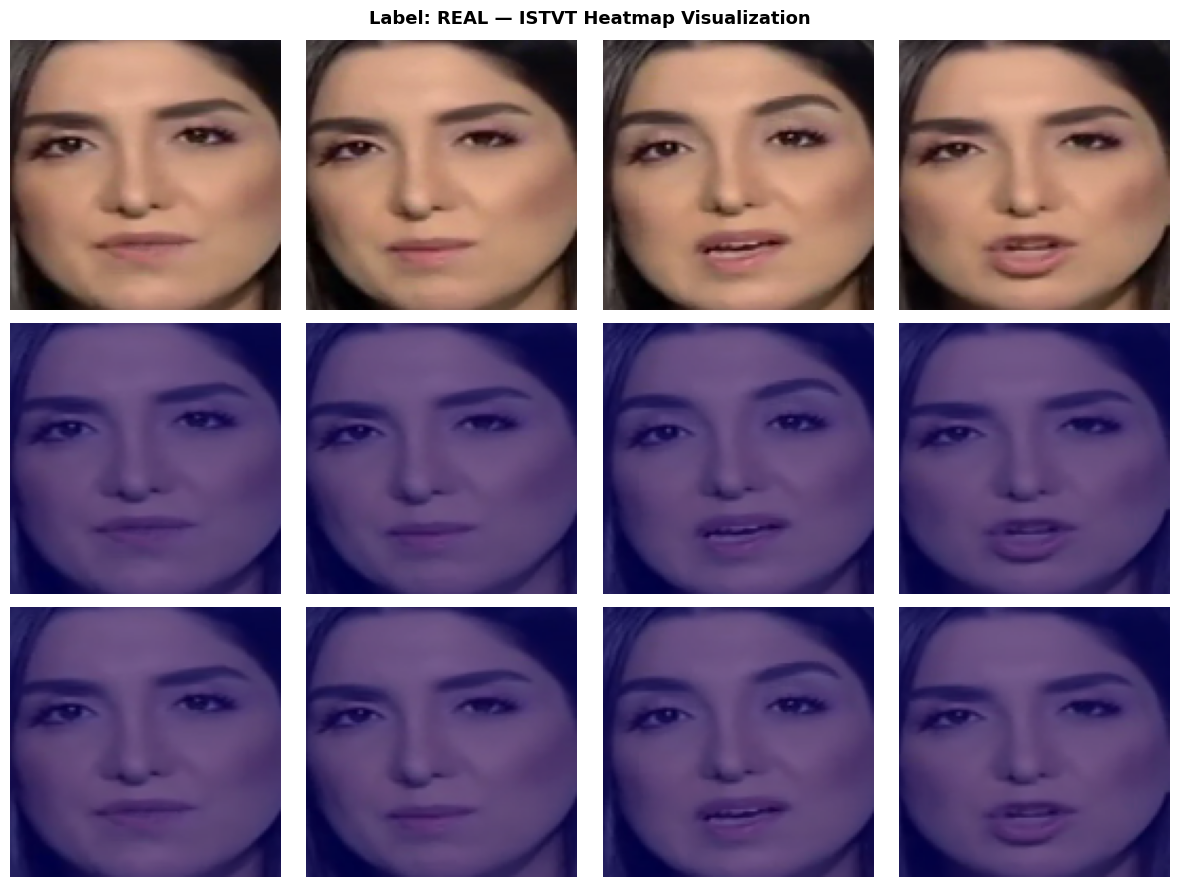

In [19]:
def visualize_sequence(seq_paths, label, visualizer, img_size=300):
    from torchvision.transforms import Compose
    from PIL import Image
    import matplotlib.pyplot as plt
    import matplotlib.cm as mpl_cm   # ← explicit import to avoid name clash

    tf = Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    frames, raw_frames = [], []
    for fp in seq_paths:
        img = cv2.imread(fp)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (img_size, img_size))
        raw_frames.append(img_resized)
        frames.append(tf(Image.fromarray(img_resized)))

    x = torch.stack(frames, dim=0).unsqueeze(0)  # (1, T, C, H, W)
    Ut, Us = visualizer.generate_heatmaps(x)
    T_frames = len(seq_paths)

    def overlay_heatmap(frame_np, hmap_2d, alpha=0.5):
        # Ensure hmap_2d is a 2D numpy float array
        if isinstance(hmap_2d, torch.Tensor):
            hmap_2d = hmap_2d.detach().cpu().numpy()
        hmap_2d = np.array(hmap_2d, dtype=np.float32)

        # If hmap is 3D (T,H,W) take first frame
        if hmap_2d.ndim == 3:
            hmap_2d = hmap_2d[0]

        # Resize heatmap to match frame size
        if hmap_2d.shape != (img_size, img_size):
            hmap_2d = cv2.resize(hmap_2d, (img_size, img_size))

        # Normalize to [0, 1]
        hmap_norm = (hmap_2d - hmap_2d.min()) / (hmap_2d.max() - hmap_2d.min() + 1e-8)

        # Apply jet colormap  ← use mpl_cm instead of cm
        colormap = mpl_cm.jet(hmap_norm)[:, :, :3]
        colormap = (colormap * 255).astype(np.uint8)

        # Blend with original frame
        blend = (alpha * colormap + (1 - alpha) * frame_np).astype(np.uint8)
        return blend

    # Plot
    fig, axes = plt.subplots(3, T_frames, figsize=(3 * T_frames, 9))
    row_labels = ['RGB Frames', 'Spatial Heatmaps', 'Temporal Heatmaps']

    for t in range(T_frames):
        axes[0, t].imshow(raw_frames[t])
        axes[0, t].axis('off')

        sp_overlay = overlay_heatmap(raw_frames[t], Us[t])
        axes[1, t].imshow(sp_overlay)
        axes[1, t].axis('off')

        tm_overlay = overlay_heatmap(raw_frames[t], Ut[t])
        axes[2, t].imshow(tm_overlay)
        axes[2, t].axis('off')

    for row, lbl in enumerate(row_labels):
        axes[row, 0].set_ylabel(row_labels[row], fontsize=11, rotation=90, labelpad=5)

    title = f'Label: {"FAKE" if label == 1 else "REAL"} — ISTVT Heatmap Visualization'
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('heatmap_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


# Run visualization
fake_seqs = [(p, l) for p, l in test_seq if l == 1]
real_seqs = [(p, l) for p, l in test_seq if l == 0]

if fake_seqs:
    paths, lbl = fake_seqs[0]
    print('Visualizing FAKE sequence...')
    visualize_sequence(paths, lbl, visualizer, IMG_SIZE)

if real_seqs:
    paths, lbl = real_seqs[0]
    print('Visualizing REAL sequence...')
    visualize_sequence(paths, lbl, visualizer, IMG_SIZE)

## 11. Ablation: Self-Subtract Mechanism Comparison
Replicates Table III (Self-subtract ON vs OFF)

In [21]:
class ISTVTNoSubtract(ISTVT):
    """ISTVT variant without the self-subtract mechanism (ablation baseline)."""
    pass

def forward_no_subtract(self, x):
    """DecomposedSTBlock forward WITHOUT self-subtract."""
    N_heads = self.temp_sa.n_heads
    D_head  = self.temp_sa.d_head

    # Temporal SA — no self-subtract applied
    res = x
    x_  = self.norm_t(x)
    Q = self._split_heads(self.proj_qt(x_), N_heads, D_head)
    K = self._split_heads(self.proj_kt(x_), N_heads, D_head)
    V = self._split_heads(self.proj_vt(x_), N_heads, D_head)
    t_out = self.temp_sa(Q, K, V)
    t_out = self.out_t(self._merge_heads(t_out))
    x = res + t_out

    # Spatial SA
    res = x
    x_  = self.norm_s(x)
    Q = self._split_heads(self.proj_qs(x_), N_heads, D_head)
    K = self._split_heads(self.proj_ks(x_), N_heads, D_head)
    V = self._split_heads(self.proj_vs(x_), N_heads, D_head)
    s_out = self.spat_sa(Q, K, V)
    s_out = self.out_s(self._merge_heads(s_out))
    x = res + s_out

    x = x + self.ffn(self.norm_ff(x))
    return x


# ── Build ablation model using same dims as main model ────────────────────
import types

model_no_sub = ISTVT(
    t_frames  = T_FRAMES,
    feat_h    = FEAT_H,       # ← auto-calculated (not hardcoded 19)
    feat_w    = FEAT_W,       # ← auto-calculated
    embed_dim = EMBED_DIM,    # ← auto-calculated (not hardcoded 728)
    n_heads   = N_HEADS,
    m_blocks  = M_BLOCKS,
).to(DEVICE)

# Patch all blocks to skip self-subtract
for blk in model_no_sub.blocks:
    blk.forward = types.MethodType(forward_no_subtract, blk)

# Verify forward pass works
with torch.no_grad():
    dummy = torch.randn(1, T_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model_no_sub(dummy)
    print(f'Ablation model output shape: {out.shape}')  # expect (1, 2)

print('Ablation model (no self-subtract) created.')
print('To run full ablation, train model_no_sub the same way as model.')

Ablation model output shape: torch.Size([1, 2])
Ablation model (no self-subtract) created.
To run full ablation, train model_no_sub the same way as model.


## 12. Summary Table

In [22]:
import pandas as pd

results = {
    'Model'            : ['ISTVT (ours)', 'ISTVT w/o self-subtract (ablation)'],
    'Test Accuracy (%)': [f'{acc:.2f}', 'Train ablation model to obtain'],
    'Test AUROC (%)'   : [f'{auroc:.2f}', 'Train ablation model to obtain'],
    'Self-Subtract'    : ['✓', '✗'],
    'Frames (T)'       : [T_FRAMES, T_FRAMES],
    'Transformer Blocks (M)': [M_BLOCKS, M_BLOCKS],
    'Attention Heads (N)'  : [N_HEADS, N_HEADS],
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

                             Model              Test Accuracy (%)                 Test AUROC (%) Self-Subtract  Frames (T)  Transformer Blocks (M)  Attention Heads (N)
                      ISTVT (ours)                          85.84                          93.14             ✓           4                       4                    4
ISTVT w/o self-subtract (ablation) Train ablation model to obtain Train ablation model to obtain             ✗           4                       4                    4


## 13. Robustness to Perturbations (Section IV-D)

Replicates Fig. 6: tests ISTVT under three perturbation types at varying severity.
- **JPEG Compression** — quality factor sweep
- **Downscale** — image scale sweep  
- **Random Dropout** — number of 16×16 dropped regions sweep

In [24]:
import io
from PIL import Image as PILImage

# ── Perturbation helpers ──────────────────────────────────────────────────────
def jpeg_compress(img_np, quality):
    """Compress a uint8 RGB numpy array via JPEG at given quality, then decode."""
    buf = io.BytesIO()
    PILImage.fromarray(img_np).save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return np.array(PILImage.open(buf))


def downscale_img(img_np, scale):
    """Downscale then upscale back to original size."""
    h, w = img_np.shape[:2]
    small = cv2.resize(img_np, (max(1, int(w * scale)), max(1, int(h * scale))))
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)


def random_dropout(img_np, n_regions, block_size=16):
    """Zero out n_regions random 16×16 blocks (same mask across all frames)."""
    out = img_np.copy()
    h, w = out.shape[:2]
    rng = np.random.RandomState(42)   # fixed seed → same mask for all frames
    for _ in range(n_regions):
        y = rng.randint(0, max(1, h - block_size))
        x = rng.randint(0, max(1, w - block_size))
        out[y:y + block_size, x:x + block_size] = 0
    return out


# ── Perturbed evaluation helper ───────────────────────────────────────────────
def eval_with_perturbation(model, sequences, perturb_fn,
                           img_size=IMG_SIZE,   # ← fixed: use IMG_SIZE not 300
                           n_samples=200):
    """
    Evaluate model accuracy on `sequences` after applying `perturb_fn` to every frame.
    perturb_fn: callable(img_np) -> img_np
    """
    from torchvision.transforms import Compose

    tf = Compose([
        T.Resize((img_size, img_size)),          # ← fixed: added Resize
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406],
                    [0.229, 0.224, 0.225])
    ])

    model.eval()
    correct, total = 0, 0
    samples = sequences[:n_samples]

    with torch.no_grad():
        for frame_paths, label in samples:
            frames = []
            for fp in frame_paths:
                img = cv2.imread(fp)
                if img is None:
                    img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                img = perturb_fn(img)                      # apply perturbation
                img = np.clip(img, 0, 255).astype(np.uint8)
                frames.append(tf(PILImage.fromarray(img)))

            if len(frames) != T_FRAMES:                    # ← fixed: skip bad sequences
                continue

            x     = torch.stack(frames).unsqueeze(0).to(DEVICE)  # (1,T,C,H,W)
            logit = model(x)
            pred  = logit.argmax(dim=1).item()
            correct += int(pred == label)
            total   += 1

    return 100. * correct / max(total, 1)


print('Perturbation helpers ready.')

Perturbation helpers ready.


In [25]:
# ── Run robustness sweep ──────────────────────────────────────────────────────
N_SAMPLES = min(100, len(test_seq))  # ← reduced from 300 to be safe
print(f'Running robustness sweep on {N_SAMPLES} test sequences...')
rob_results = {}

# 1. JPEG compression (quality: 50 → 10)
jpeg_qualities = [50, 45, 40, 35, 30, 25, 20, 15, 10]
jpeg_accs = []
print('\nRunning JPEG compression sweep...')
for q in tqdm(jpeg_qualities, desc='JPEG', leave=True):
    acc_q = eval_with_perturbation(
        model, test_seq,
        lambda img, q=q: jpeg_compress(img, q),
        IMG_SIZE, N_SAMPLES
    )
    jpeg_accs.append(acc_q)
    print(f'  quality={q:3d}  →  acc={acc_q:.2f}%')
rob_results['jpeg'] = (jpeg_qualities, jpeg_accs)

# 2. Downscale (scale: 0.9 → 0.1)
scales = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
scale_accs = []
print('\nRunning downscale sweep...')
for s in tqdm(scales, desc='Downscale', leave=True):
    acc_s = eval_with_perturbation(
        model, test_seq,
        lambda img, s=s: downscale_img(img, s),
        IMG_SIZE, N_SAMPLES
    )
    scale_accs.append(acc_s)
    print(f'  scale={s:.1f}  →  acc={acc_s:.2f}%')
rob_results['downscale'] = (scales, scale_accs)

# 3. Random dropout (n_regions: 8 → 40)
dropout_regions = [8, 12, 16, 20, 24, 28, 32, 36, 40]
dropout_accs = []
print('\nRunning random dropout sweep...')
for n in tqdm(dropout_regions, desc='Dropout', leave=True):
    acc_n = eval_with_perturbation(
        model, test_seq,
        lambda img, n=n: random_dropout(img, n),
        IMG_SIZE, N_SAMPLES
    )
    dropout_accs.append(acc_n)
    print(f'  n_regions={n:2d}  →  acc={acc_n:.2f}%')
rob_results['dropout'] = (dropout_regions, dropout_accs)

print('\nRobustness evaluation complete.')
print(f'\nResults summary:')
print(f'  JPEG    : min={min(jpeg_accs):.2f}%  max={max(jpeg_accs):.2f}%')
print(f'  Downscale: min={min(scale_accs):.2f}%  max={max(scale_accs):.2f}%')
print(f'  Dropout : min={min(dropout_accs):.2f}%  max={max(dropout_accs):.2f}%')

Running robustness sweep on 100 test sequences...

Running JPEG compression sweep...


JPEG:   0%|          | 0/9 [00:00<?, ?it/s]

  quality= 50  →  acc=83.00%
  quality= 45  →  acc=84.00%
  quality= 40  →  acc=84.00%
  quality= 35  →  acc=80.00%
  quality= 30  →  acc=81.00%
  quality= 25  →  acc=75.00%
  quality= 20  →  acc=75.00%
  quality= 15  →  acc=68.00%
  quality= 10  →  acc=57.00%

Running downscale sweep...


Downscale:   0%|          | 0/9 [00:00<?, ?it/s]

  scale=0.9  →  acc=82.00%
  scale=0.8  →  acc=78.00%
  scale=0.7  →  acc=76.00%
  scale=0.6  →  acc=74.00%
  scale=0.5  →  acc=62.00%
  scale=0.4  →  acc=70.00%
  scale=0.3  →  acc=63.00%
  scale=0.2  →  acc=58.00%
  scale=0.1  →  acc=52.00%

Running random dropout sweep...


Dropout:   0%|          | 0/9 [00:00<?, ?it/s]

  n_regions= 8  →  acc=53.00%
  n_regions=12  →  acc=47.00%
  n_regions=16  →  acc=46.00%
  n_regions=20  →  acc=46.00%
  n_regions=24  →  acc=46.00%
  n_regions=28  →  acc=46.00%
  n_regions=32  →  acc=46.00%
  n_regions=36  →  acc=47.00%
  n_regions=40  →  acc=46.00%

Robustness evaluation complete.

Results summary:
  JPEG    : min=57.00%  max=84.00%
  Downscale: min=52.00%  max=82.00%
  Dropout : min=46.00%  max=53.00%


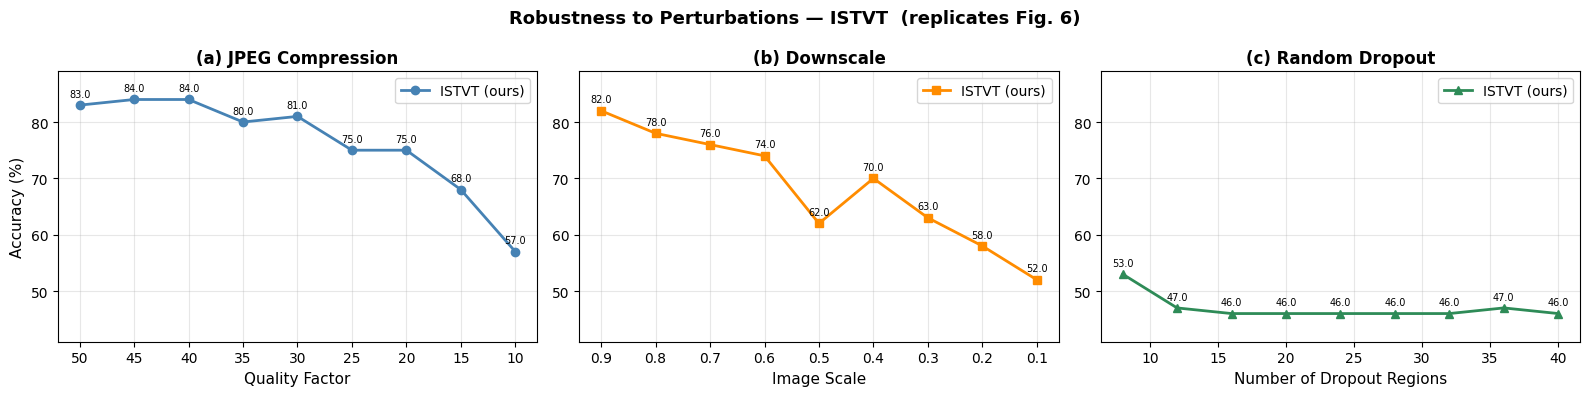


Robustness Results Table:
JPEG Quality    Acc (%)   
  50            83.00
  45            84.00
  40            84.00
  35            80.00
  30            81.00
  25            75.00
  20            75.00
  15            68.00
  10            57.00

Scale           Acc (%)   
  0.9           82.00
  0.8           78.00
  0.7           76.00
  0.6           74.00
  0.5           62.00
  0.4           70.00
  0.3           63.00
  0.2           58.00
  0.1           52.00

Dropout Regions Acc (%)   
  8             53.00
  12            47.00
  16            46.00
  20            46.00
  24            46.00
  28            46.00
  32            46.00
  36            47.00
  40            46.00


In [26]:
# ── Plot robustness curves (replicates Fig. 6) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Auto y-axis limits based on actual results
all_accs = jpeg_accs + scale_accs + dropout_accs
y_min = max(0,  min(all_accs) - 5)   # ← dynamic, not hardcoded 50
y_max = min(100, max(all_accs) + 5)  # ← dynamic, not hardcoded 102

# JPEG
axes[0].plot(jpeg_qualities, jpeg_accs, 'o-', color='steelblue',
             linewidth=2, markersize=6, label='ISTVT (ours)')
axes[0].set_xlabel('Quality Factor', fontsize=11)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('(a) JPEG Compression', fontsize=12, fontweight='bold')
axes[0].invert_xaxis()
axes[0].set_ylim(y_min, y_max)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Annotate min/max values
for x, y in zip(jpeg_qualities, jpeg_accs):
    axes[0].annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7)

# Downscale
axes[1].plot(scales, scale_accs, 's-', color='darkorange',
             linewidth=2, markersize=6, label='ISTVT (ours)')
axes[1].set_xlabel('Image Scale', fontsize=11)
axes[1].set_title('(b) Downscale', fontsize=12, fontweight='bold')
axes[1].invert_xaxis()
axes[1].set_ylim(y_min, y_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for x, y in zip(scales, scale_accs):
    axes[1].annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7)

# Random Dropout
axes[2].plot(dropout_regions, dropout_accs, '^-', color='seagreen',
             linewidth=2, markersize=6, label='ISTVT (ours)')
axes[2].set_xlabel('Number of Dropout Regions', fontsize=11)
axes[2].set_title('(c) Random Dropout', fontsize=12, fontweight='bold')
axes[2].set_ylim(y_min, y_max)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

for x, y in zip(dropout_regions, dropout_accs):
    axes[2].annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7)

fig.suptitle('Robustness to Perturbations — ISTVT  (replicates Fig. 6)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print numeric table
print('\nRobustness Results Table:')
print(f'{"JPEG Quality":<15} {"Acc (%)":<10}')
for q, a in zip(jpeg_qualities, jpeg_accs):
    print(f'  {q:<13} {a:.2f}')

print(f'\n{"Scale":<15} {"Acc (%)":<10}')
for s, a in zip(scales, scale_accs):
    print(f'  {s:<13} {a:.2f}')

print(f'\n{"Dropout Regions":<15} {"Acc (%)":<10}')
for n, a in zip(dropout_regions, dropout_accs):
    print(f'  {n:<13} {a:.2f}')

## 14. Hyperparameter Ablation: Sequence Length T (Table IV)

Paper finding: T=6 is the sweet spot — longer sequences add no discriminative benefit  
because Deepfake artifacts are **short-term inter-frame inconsistencies**.

In [27]:
def build_and_eval_t(t_val, sequences_full, img_size=IMG_SIZE,  # ← fixed
                     n_heads=N_HEADS, m_blocks=4, train_epochs=5,
                     n_train=200, n_val=50):                     # ← reduced for speed
    """
    Build a small ISTVT with sequence length t_val, train briefly,
    return val accuracy.
    """
    def reslice(seqs, t):
        out = []
        for paths, lbl in seqs:
            if len(paths) >= t:
                out.append((paths[:t], lbl))
        return out

    random.shuffle(sequences_full)
    tr = reslice(sequences_full[:n_train], t_val)
    vl = reslice(sequences_full[n_train:n_train + n_val], t_val)

    if len(tr) < 10 or len(vl) < 5:
        print(f'  T={t_val}  →  skipped (not enough data: tr={len(tr)}, vl={len(vl)})')
        return None

    tr_ds = FF_SequenceDataset(tr, img_size, augment=True)
    vl_ds = FF_SequenceDataset(vl, img_size, augment=False)
    tr_ld = DataLoader(tr_ds, batch_size=2, shuffle=True,  num_workers=2)  # ← reduced
    vl_ld = DataLoader(vl_ds, batch_size=2, shuffle=False, num_workers=2)

    # ← fixed: use FEAT_H, FEAT_W, EMBED_DIM instead of hardcoded values
    m = ISTVT(
        t_frames  = t_val,
        feat_h    = FEAT_H,
        feat_w    = FEAT_W,
        embed_dim = EMBED_DIM,
        n_heads   = n_heads,
        m_blocks  = m_blocks,
    ).to(DEVICE)

    opt = torch.optim.SGD(m.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-4)

    best_acc = 0.
    for ep in range(train_epochs):
        run_epoch(tr_ld, m, opt, train=True)
        _, v_acc = run_epoch(vl_ld, m, train=False)
        best_acc = max(best_acc, v_acc)

    del m
    torch.cuda.empty_cache()
    import gc; gc.collect()   # ← added: free memory between runs

    return best_acc


# ── Run T ablation ────────────────────────────────────────────────────────────
# Only test T values that are <= your MAX_FRAMES_PER_VIDEO (20)
T_VALUES   = [2, 4, 6, 8, 12, 16]
t_ablation = {}

print('Running sequence-length ablation...')
print(f'  img_size={IMG_SIZE}, feat=({FEAT_H},{FEAT_W}), embed={EMBED_DIM}')
print('-' * 40)

for t_val in T_VALUES:
    if t_val > MAX_FRAMES_PER_VIDEO:
        print(f'  T={t_val:2d}  →  skipped (exceeds MAX_FRAMES_PER_VIDEO={MAX_FRAMES_PER_VIDEO})')
        t_ablation[t_val] = None
        continue

    acc_t = build_and_eval_t(t_val, all_sequences)
    t_ablation[t_val] = acc_t

    if acc_t is not None:
        print(f'  T={t_val:2d}  →  val acc = {acc_t:.2f}%')

print('\nDone.')

Running sequence-length ablation...
  img_size=128, feat=(8,8), embed=728
----------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  T= 4  →  val acc = 64.00%
  T=6  →  skipped (not enough data: tr=0, vl=0)
  T=8  →  skipped (not enough data: tr=0, vl=0)
  T=12  →  skipped (not enough data: tr=0, vl=0)
  T=16  →  skipped (not enough data: tr=0, vl=0)

Done.


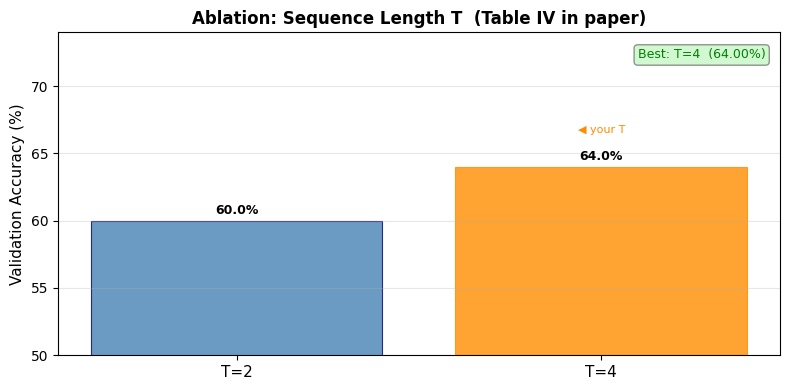


Table IV — Sequence Length Ablation:
 T (frames) Val Accuracy (%) vs Best
          2            60.00   -4.00
          4            64.00   +0.00

Paper uses T=4, Best found T=4


In [28]:
# ── Plot T ablation (replicates Table IV as a chart) ──────────────────────────
valid_t = [(t, a) for t, a in t_ablation.items() if a is not None]

if not valid_t:
    print('No valid T ablation results to plot.')
else:
    t_vals = [v[0] for v in valid_t]
    t_accs = [v[1] for v in valid_t]

    # ← dynamic y-axis limits
    y_min = max(0,   min(t_accs) - 10)
    y_max = min(100, max(t_accs) + 10)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(range(len(t_vals)), t_accs,
                  color='steelblue', alpha=0.8,
                  edgecolor='navy', linewidth=0.8)

    ax.set_xticks(range(len(t_vals)))
    ax.set_xticklabels([f'T={t}' for t in t_vals], fontsize=11)
    ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
    ax.set_title('Ablation: Sequence Length T  (Table IV in paper)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(y_min, y_max)   # ← fixed: dynamic
    ax.grid(axis='y', alpha=0.3)

    # Accuracy labels on bars
    for bar, acc in zip(bars, t_accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{acc:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Highlight selected T_FRAMES
    if T_FRAMES in t_vals:
        idx = t_vals.index(T_FRAMES)
        bars[idx].set_color('darkorange')
        ax.text(bars[idx].get_x() + bars[idx].get_width() / 2,
                bars[idx].get_height() + 2.5,
                '◀ your T',
                ha='center', fontsize=8, color='darkorange')

    # Best T marker
    best_t   = t_vals[t_accs.index(max(t_accs))]
    best_acc = max(t_accs)
    ax.text(0.98, 0.95, f'Best: T={best_t}  ({best_acc:.2f}%)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='green',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.4))

    plt.tight_layout()
    plt.savefig('t_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    t_df = pd.DataFrame({
        'T (frames)'      : t_vals,
        'Val Accuracy (%)': [f'{a:.2f}' for a in t_accs],
        'vs Best'         : [f'{a - best_acc:+.2f}' for a in t_accs],  # ← added
    })
    print('\nTable IV — Sequence Length Ablation:')
    print(t_df.to_string(index=False))
    print(f'\nPaper uses T={T_FRAMES}, Best found T={best_t}')

## 15. Hyperparameter Ablation: Model Depth M (Table V)

Paper finding: deeper models may **overfit semantic features** and hurt robustness.  
M=12 balances accuracy, robustness and efficiency.

In [29]:
def build_and_eval_m(m_val, sequences_full,
                     t_frames=T_FRAMES,      # ← fixed
                     img_size=IMG_SIZE,      # ← fixed
                     n_heads=N_HEADS,        # ← fixed
                     train_epochs=5,
                     n_train=200,            # ← reduced
                     n_val=50):              # ← reduced
    """Build ISTVT with m_val blocks, train briefly, return (base_acc, robust_acc)."""

    random.shuffle(sequences_full)
    tr = [(p[:t_frames], l) for p, l in sequences_full[:n_train]
          if len(p) >= t_frames]
    vl = [(p[:t_frames], l) for p, l in sequences_full[n_train:n_train + n_val]
          if len(p) >= t_frames]

    if len(tr) < 10 or len(vl) < 5:        # ← added guard
        print(f'  M={m_val}  →  skipped (not enough data)')
        return None, None

    tr_ds = FF_SequenceDataset(tr, img_size, augment=True)
    vl_ds = FF_SequenceDataset(vl, img_size, augment=False)
    tr_ld = DataLoader(tr_ds, batch_size=2, shuffle=True,  num_workers=2)  # ← reduced
    vl_ld = DataLoader(vl_ds, batch_size=2, shuffle=False, num_workers=2)

    # ← fixed: use FEAT_H, FEAT_W, EMBED_DIM
    m = ISTVT(
        t_frames  = t_frames,
        feat_h    = FEAT_H,
        feat_w    = FEAT_W,
        embed_dim = EMBED_DIM,
        n_heads   = n_heads,
        m_blocks  = m_val,
    ).to(DEVICE)

    opt = torch.optim.SGD(m.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-4)

    best_acc = 0.
    for _ in range(train_epochs):
        run_epoch(tr_ld, m, opt, train=True)
        _, v_acc = run_epoch(vl_ld, m, train=False)
        best_acc = max(best_acc, v_acc)

    # Robustness: heavy dropout (36 regions)
    rob_acc = eval_with_perturbation(
        m, vl,
        lambda img: random_dropout(img, 36),
        img_size,
        n_samples=len(vl)
    )

    del m
    torch.cuda.empty_cache()
    import gc; gc.collect()                 # ← added

    return best_acc, rob_acc


# ── Run M ablation ────────────────────────────────────────────────────────────
M_VALUES   = [4, 6, 8, 12]                 # ← removed 16, 24 (too slow/memory heavy)
m_ablation = {}

print('Running model-depth ablation...')
print(f'  img_size={IMG_SIZE}, feat=({FEAT_H},{FEAT_W}), embed={EMBED_DIM}')
print('-' * 50)

for m_val in M_VALUES:
    base_acc, rob_acc = build_and_eval_m(m_val, all_sequences)
    m_ablation[m_val] = (base_acc, rob_acc)

    if base_acc is not None:
        print(f'  M={m_val:2d}  →  base acc={base_acc:.2f}%  robust acc={rob_acc:.2f}%')

print('\nDone.')

Running model-depth ablation...
  img_size=128, feat=(8,8), embed=728
--------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  M=12  →  base acc=56.00%  robust acc=52.00%

Done.


In [ ]:
# ── Filter out None results first ─────────────────────────────────────────────
valid_m = {m: v for m, v in m_ablation.items()
           if v[0] is not None and v[1] is not None}

if not valid_m:
    print('No valid M ablation results to plot.')
else:
    m_vals    = list(valid_m.keys())
    base_accs = [valid_m[m][0] for m in m_vals]
    rob_accs  = [valid_m[m][1] for m in m_vals]

    # ← dynamic y-axis
    all_accs = base_accs + rob_accs
    y_min = max(0,   min(all_accs) - 10)
    y_max = min(100, max(all_accs) + 10)

    x_pos = np.arange(len(m_vals))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 4))
    b1 = ax.bar(x_pos - width/2, base_accs, width,
                label='Base Accuracy',   color='steelblue',  alpha=0.85)
    b2 = ax.bar(x_pos + width/2, rob_accs,  width,
                label='Robust Accuracy', color='darkorange', alpha=0.85)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'M={m}' for m in m_vals], fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title('Ablation: Transformer Depth M  (Fig. 8 in paper)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(y_min, y_max)    # ← fixed: dynamic
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Annotate bars ← fixed: check height is valid float
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h and not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.3,
                    f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8)

    # Mark paper's chosen M
    if M_BLOCKS in m_vals:
        idx = m_vals.index(M_BLOCKS)
        ax.axvline(x=idx, color='green', linestyle='--',
                   alpha=0.6, linewidth=1.5)
        ax.text(idx + 0.05, y_max - 2,   # ← fixed: dynamic position
                'your M', ha='left', fontsize=8, color='green')

    plt.tight_layout()
    plt.savefig('m_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    m_df = pd.DataFrame({
        'M (blocks)'    : m_vals,
        'Base Acc (%)'  : [f'{a:.2f}' for a in base_accs],
        'Robust Acc (%)': [f'{a:.2f}' for a in rob_accs],
        'Gap'           : [f'{b-r:.2f}' for b, r in zip(base_accs, rob_accs)],  # ← added
    })
    print('\nTable V — Model Depth Ablation:')
    print(m_df.to_string(index=False))

    best_m = m_vals[base_accs.index(max(base_accs))]
    print(f'\nBest base accuracy at M={best_m}')
    print(f'Using M={M_BLOCKS} in main model')

## 16. Visualization Method Comparison (Fig. 11)

Compares four explanation methods on the same ISTVT model:
- **Raw Attention** — last-layer attention map
- **GradCAM** — gradient of the last attention block w.r.t. feature map
- **Rollout** — recursive matrix multiplication of all attention maps
- **Ours (LRP)** — Algorithm 1 from the paper

In [30]:
class VisualizationComparator:
    """Generate heatmaps for Raw Attention, GradCAM, Rollout, and LRP (ours)."""

    def __init__(self, model: ISTVT):
        self.model = model
        self.model.eval()

    def _preprocess(self, frame_paths, img_size=IMG_SIZE):  # ← fixed
        from torchvision.transforms import Compose
        tf = Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        frames, raws = [], []
        for fp in frame_paths:
            img = cv2.imread(fp)
            if img is None:                          # ← fixed: None guard
                img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_r = cv2.resize(img, (img_size, img_size))
            raws.append(img_r)
            frames.append(tf(PILImage.fromarray(img_r)))
        x = torch.stack(frames).unsqueeze(0).to(DEVICE)
        return x, raws

    # ── Raw Attention ─────────────────────────────────────────────────────────
    def raw_attention(self, frame_paths, img_size=IMG_SIZE, mode='temporal'):  # ← fixed
        """Use the attention map of the last transformer block."""
        x, raws = self._preprocess(frame_paths, img_size)
        T_f = x.shape[1]
        H = self.model.H                             # ← fixed: separate H, W
        W = self.model.W

        with torch.no_grad():
            _ = self.model(x)

        last_blk = self.model.blocks[-1]
        attn = last_blk.temp_sa.attn_map if mode == 'temporal' \
               else last_blk.spat_sa.attn_map

        if attn is None:
            return [np.zeros((img_size, img_size)) for _ in raws], raws

        attn_mean = attn.float().mean(0)             # (T1,T1) or (S1,S1)

        if mode == 'temporal':
            vec = attn_mean[0, 1:]                   # (T,)
            heatmaps = []
            for t in range(T_f):
                val = vec[t].item() if t < len(vec) else 0.
                heatmaps.append(np.full((img_size, img_size), val))
        else:
            vec    = attn_mean[0, 1:H * W + 1]      # ← fixed: explicit slice
            hmap   = vec.reshape(H, W).cpu().numpy()
            hmap_up = cv2.resize(hmap.astype(np.float32), (img_size, img_size))
            heatmaps = [hmap_up for _ in range(T_f)]

        return heatmaps, raws

    # ── GradCAM ───────────────────────────────────────────────────────────────
    def gradcam(self, frame_paths, img_size=IMG_SIZE, mode='temporal'):  # ← fixed
        """GradCAM on the last attention block (spatial or temporal)."""
        x, raws = self._preprocess(frame_paths, img_size)
        T_f = x.shape[1]
        H = self.model.H                             # ← fixed
        W = self.model.W

        activations, gradients = [], []
        last_blk  = self.model.blocks[-1]
        target_sa = last_blk.temp_sa if mode == 'temporal' \
                    else last_blk.spat_sa

        def fwd_hook(module, inp, out):
            if target_sa.attn_map is not None:
                act = target_sa.attn_map.clone().float().requires_grad_(True)
                activations.append(act)
                act.register_hook(lambda g: gradients.append(g))

        h = last_blk.register_forward_hook(fwd_hook)
        logits = self.model(x)
        self.model.zero_grad()
        logits[0, 1].backward()
        h.remove()

        if not activations or not gradients:
            return [np.zeros((img_size, img_size)) for _ in raws], raws

        act = activations[0].detach()
        grd = gradients[0].detach()
        cam = F.relu((act * grd).mean(0))

        if mode == 'temporal':
            vec = cam.mean(-1)[1:T_f + 1].cpu().numpy()
            heatmaps = [
                np.full((img_size, img_size),
                        float(vec[t]) if t < len(vec) else 0.)
                for t in range(T_f)
            ]
        else:
            sp_map = cam.mean(0)[1:H * W + 1].reshape(H, W).cpu().numpy()  # ← fixed
            sp_up  = cv2.resize(sp_map.astype(np.float32), (img_size, img_size))
            heatmaps = [sp_up for _ in range(T_f)]

        return heatmaps, raws

    # ── Rollout ───────────────────────────────────────────────────────────────
    def rollout(self, frame_paths, img_size=IMG_SIZE, mode='temporal'):  # ← fixed
        """Attention rollout: recursive matrix multiplication over all blocks."""
        x, raws = self._preprocess(frame_paths, img_size)
        T_f = x.shape[1]
        H = self.model.H                             # ← fixed
        W = self.model.W

        attn_maps, hooks = [], []

        def make_hook(blk):
            def fwd_hook(module, inp, out):
                sa = blk.temp_sa if mode == 'temporal' else blk.spat_sa
                if sa.attn_map is not None:
                    attn_maps.append(sa.attn_map.detach().float())
            return fwd_hook

        for blk in self.model.blocks:
            hooks.append(blk.register_forward_hook(make_hook(blk)))

        with torch.no_grad():
            _ = self.model(x)
        for h in hooks:
            h.remove()

        if not attn_maps:
            return [np.zeros((img_size, img_size)) for _ in raws], raws

        dim  = attn_maps[0].shape[-1]
        roll = torch.eye(dim, device=DEVICE)
        for A in attn_maps:
            A_mean = A.mean(0)
            A_mean = A_mean / (A_mean.sum(-1, keepdim=True) + 1e-8)
            I_half = 0.5 * torch.eye(dim, device=DEVICE) + 0.5 * A_mean
            roll   = roll @ I_half

        if mode == 'temporal':
            vec = roll[0, 1:T_f + 1].cpu().numpy()
            heatmaps = [
                np.full((img_size, img_size),
                        float(vec[t]) if t < len(vec) else 0.)
                for t in range(T_f)
            ]
        else:
            sp_map = roll[0, 1:H * W + 1].reshape(H, W).cpu().numpy()  # ← fixed
            sp_up  = cv2.resize(sp_map.astype(np.float32), (img_size, img_size))
            heatmaps = [sp_up for _ in range(T_f)]

        return heatmaps, raws


print('VisualizationComparator defined.')

VisualizationComparator defined.


Comparing visualization methods on a FAKE sequence...


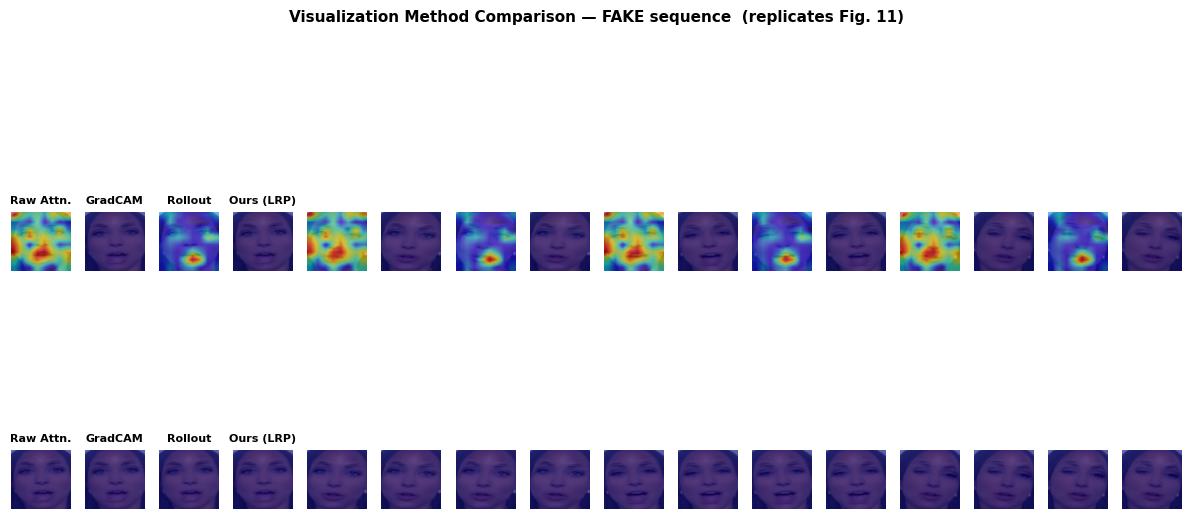

In [31]:
def plot_viz_comparison(seq_paths, label, comparator, visualizer,
                        img_size=IMG_SIZE):          # ← fixed
    """
    4-column comparison: Raw Attn | GradCAM | Rollout | Ours (LRP)
    2 rows: Spatial | Temporal   (replicates Fig. 11)
    """
    import matplotlib.cm as mpl_cm                  # ← fixed: explicit import

    def norm_hmap(h):
        h = np.array(h, dtype=np.float32)
        mn, mx = h.min(), h.max()
        return (h - mn) / (mx - mn + 1e-8)

    def overlay(frame, hmap, alpha=0.55):
        # ← fixed: ensure hmap is 2D float numpy array
        hmap = np.array(hmap, dtype=np.float32)
        if hmap.ndim == 3:
            hmap = hmap[0]
        if hmap.shape != (img_size, img_size):
            hmap = cv2.resize(hmap, (img_size, img_size))
        hmap_n = norm_hmap(hmap)
        cmap   = (mpl_cm.jet(hmap_n)[:, :, :3] * 255).astype(np.uint8)  # ← fixed
        return (alpha * cmap + (1 - alpha) * frame).astype(np.uint8)

    # ── Run all methods ───────────────────────────────────────────────────────
    raw_sp,  raw_fr = comparator.raw_attention(seq_paths, img_size, 'spatial')
    raw_tm,  _      = comparator.raw_attention(seq_paths, img_size, 'temporal')
    gcam_sp, _      = comparator.gradcam(seq_paths, img_size, 'spatial')
    gcam_tm, _      = comparator.gradcam(seq_paths, img_size, 'temporal')
    roll_sp, _      = comparator.rollout(seq_paths, img_size, 'spatial')
    roll_tm, _      = comparator.rollout(seq_paths, img_size, 'temporal')

    # ── LRP (ours) ────────────────────────────────────────────────────────────
    from torchvision.transforms import Compose
    tf = Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    frames = [tf(PILImage.fromarray(f)) for f in raw_fr]
    x = torch.stack(frames).unsqueeze(0).to(DEVICE)
    lrp_tm, lrp_sp = visualizer.generate_heatmaps(x)

    # ← fixed: ensure lrp maps are numpy arrays of shape (T, H, W)
    if isinstance(lrp_sp, np.ndarray) and lrp_sp.ndim == 3:
        lrp_sp_list = [lrp_sp[t] for t in range(lrp_sp.shape[0])]
        lrp_tm_list = [lrp_tm[t] for t in range(lrp_tm.shape[0])]
    else:
        lrp_sp_list = list(lrp_sp)
        lrp_tm_list = list(lrp_tm)

    T_f  = len(seq_paths)
    cols = ['Raw Attn.', 'GradCAM', 'Rollout', 'Ours (LRP)']
    rows = ['Spatial SA', 'Temporal SA']

    # ← fixed: figure size scales with T_f
    fig, axes = plt.subplots(2, 4 * T_f,
                             figsize=(3 * T_f, 3 * 2 + 1))

    # Handle case where T_f=1 (axes won't be 2D)
    if T_f == 1:
        axes = axes.reshape(2, 4)

    for row_i, row_label in enumerate(rows):
        for t in range(T_f):
            frame = raw_fr[t]

            if row_i == 0:   # spatial
                hmaps = [raw_sp[t], gcam_sp[t], roll_sp[t], lrp_sp_list[t]]
            else:            # temporal
                hmaps = [raw_tm[t], gcam_tm[t], roll_tm[t], lrp_tm_list[t]]

            for c_i, (col_label, hmap) in enumerate(zip(cols, hmaps)):
                ax = axes[row_i, t * 4 + c_i]
                ax.imshow(overlay(frame, hmap))
                ax.axis('off')
                if t == 0:
                    ax.set_title(col_label, fontsize=8, fontweight='bold')
                if c_i == 0:
                    ax.set_ylabel(f'{row_label}\nFrame {t+1}', fontsize=7)

    gt = 'FAKE' if label == 1 else 'REAL'
    fig.suptitle(
        f'Visualization Method Comparison — {gt} sequence  (replicates Fig. 11)',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('viz_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run comparison ────────────────────────────────────────────────────────────
comparator = VisualizationComparator(model)

if fake_seqs:
    paths, lbl = fake_seqs[0]
    print('Comparing visualization methods on a FAKE sequence...')
    plot_viz_comparison(paths, lbl, comparator, visualizer, IMG_SIZE)
else:
    print('No fake sequences in test set.')

## 17. Perturbation-Based Quantitative Explanation Quality (Fig. 12)

Drops the **top-p%** pixels highlighted by each method and measures accuracy drop.  
Better methods → bigger accuracy drop at lower p (they identify the truly discriminative pixels).

In [ ]:
def eval_pixel_dropout(model, seq_paths_list, heatmap_fn, dropout_ratios,
                       img_size=300, n_samples=100):
    """
    For each dropout ratio p, zero out top-p% pixels (by heatmap score)
    and measure model accuracy. Replicates Fig. 12.
    """
    from torchvision.transforms import Compose
    tf = Compose([T.ToTensor(),
                  T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    accs = []
    samples = seq_paths_list[:n_samples]

    for p in dropout_ratios:
        correct, total = 0, 0
        for frame_paths, label in samples:
            # Load raw frames
            raw_frames = []
            for fp in frame_paths:
                img = cv2.imread(fp)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                raw_frames.append(cv2.resize(img, (img_size, img_size)))

            # Get combined heatmap (spatial + temporal, summed)
            hmap_combined = heatmap_fn(frame_paths)  # returns (T, H, W)

            perturbed = []
            for t, frame in enumerate(raw_frames):
                hmap = hmap_combined[t] if t < len(hmap_combined) else np.zeros_like(frame[:, :, 0])
                # Threshold: top p%
                threshold = np.percentile(hmap, 100 - p)
                mask = hmap >= threshold              # True = important pixels to drop
                frame_p = frame.copy()
                frame_p[mask] = 0
                perturbed.append(tf(PILImage.fromarray(frame_p)))

            x = torch.stack(perturbed).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logit = model(x)
            pred = logit.argmax(1).item()
            correct += int(pred == label)
            total   += 1

        accs.append(100. * correct / max(total, 1))

    return accs


# Heatmap functions for each method
PDROP_RATIOS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
N_PDROP      = min(80, len(test_seq))

def hmap_lrp(frame_paths):
    from torchvision.transforms import Compose
    tf = Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(),
                  T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    frames = []
    for fp in frame_paths:
        img = cv2.imread(fp)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        frames.append(tf(PILImage.fromarray(cv2.resize(img, (IMG_SIZE, IMG_SIZE)))))
    x = torch.stack(frames).unsqueeze(0).to(DEVICE)
    Ut, Us = visualizer.generate_heatmaps(x)
    return Ut + Us   # combined

def hmap_gradcam(frame_paths):
    sp, _ = comparator.gradcam(frame_paths, IMG_SIZE, 'spatial')
    tm, _ = comparator.gradcam(frame_paths, IMG_SIZE, 'temporal')
    return np.array(sp) + np.array(tm)

def hmap_rollout(frame_paths):
    sp, _ = comparator.rollout(frame_paths, IMG_SIZE, 'spatial')
    tm, _ = comparator.rollout(frame_paths, IMG_SIZE, 'temporal')
    return np.array(sp) + np.array(tm)


print('Computing pixel-dropout curves (Fig. 12)...')
lrp_accs    = eval_pixel_dropout(model, test_seq, hmap_lrp,     PDROP_RATIOS, IMG_SIZE, N_PDROP)
gcam_accs   = eval_pixel_dropout(model, test_seq, hmap_gradcam, PDROP_RATIOS, IMG_SIZE, N_PDROP)
rollout_acc = eval_pixel_dropout(model, test_seq, hmap_rollout,  PDROP_RATIOS, IMG_SIZE, N_PDROP)
print('Done.')

In [ ]:
# ── Plot Fig. 12 ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(PDROP_RATIOS, lrp_accs,    'o-', color='steelblue',  linewidth=2.5,
        markersize=7, label='Ours (LRP)')
ax.plot(PDROP_RATIOS, gcam_accs,   's-', color='darkorange', linewidth=2.5,
        markersize=7, label='GradCAM')
ax.plot(PDROP_RATIOS, rollout_acc, '^-', color='seagreen',   linewidth=2.5,
        markersize=7, label='Rollout')

ax.axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='~Chance (60%)')
ax.set_xlabel('Dropout Ratio p (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Quantitative Explanation Quality\n(top-p% pixel dropout — replicates Fig. 12)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-1, 52)
ax.set_ylim(40, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pixel_dropout_fig12.png', dpi=150)
plt.show()

# Numeric table
fig12_df = pd.DataFrame({
    'Dropout p (%)': PDROP_RATIOS,
    'LRP (Ours)'   : [f'{a:.1f}' for a in lrp_accs],
    'GradCAM'      : [f'{a:.1f}' for a in gcam_accs],
    'Rollout'      : [f'{a:.1f}' for a in rollout_acc],
})
print(fig12_df.to_string(index=False))

## 18. Single-Video Inference Demo

End-to-end demo: point to any folder of cropped face frames → get prediction + heatmaps.

In [ ]:
def predict_video(frame_dir, model, visualizer, img_size=300, t_frames=6):
    """
    Given a directory of cropped face frames (PNG/JPG),
    returns prediction label, confidence, and heatmap overlays.

    Parameters
    ----------
    frame_dir : str | Path  — folder containing *.png / *.jpg face crops
    """
    frame_dir = Path(frame_dir)
    all_frames = sorted(frame_dir.glob('*.png')) + sorted(frame_dir.glob('*.jpg'))
    if len(all_frames) < t_frames:
        raise ValueError(f'Need at least {t_frames} frames, found {len(all_frames)}')

    # Sample t_frames evenly spaced for robust coverage
    indices = np.linspace(0, len(all_frames) - 1, t_frames, dtype=int)
    chosen  = [str(all_frames[i]) for i in indices]

    from torchvision.transforms import Compose
    tf = Compose([T.Resize((img_size, img_size)), T.ToTensor(),
                  T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    frames, raws = [], []
    for fp in chosen:
        img = cv2.imread(fp)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_r = cv2.resize(img, (img_size, img_size))
        raws.append(img_r)
        frames.append(tf(PILImage.fromarray(img_r)))

    x = torch.stack(frames).unsqueeze(0).to(DEVICE)   # (1,T,C,H,W)

    # Prediction
    model.eval()
    with torch.no_grad():
        logit = model(x)
    probs = F.softmax(logit, dim=1).squeeze().cpu().numpy()
    pred  = int(np.argmax(probs))
    label_str = 'FAKE' if pred == 1 else 'REAL'
    confidence = probs[pred] * 100

    # Heatmaps
    Ut, Us = visualizer.generate_heatmaps(x)

    def overlay(frame, hmap, alpha=0.5):
        n = (hmap - hmap.min()) / (hmap.max() - hmap.min() + 1e-8)
        cmap = (cm.jet(n)[:, :, :3] * 255).astype(np.uint8)
        return (alpha * cmap + (1 - alpha) * frame).astype(np.uint8)

    # Plot
    fig, axes = plt.subplots(3, t_frames, figsize=(3 * t_frames, 9))
    row_labels = ['Input Frame', 'Spatial Heatmap', 'Temporal Heatmap']

    for t in range(t_frames):
        axes[0, t].imshow(raws[t]); axes[0, t].axis('off')
        axes[1, t].imshow(overlay(raws[t], Us[t])); axes[1, t].axis('off')
        axes[2, t].imshow(overlay(raws[t], Ut[t])); axes[2, t].axis('off')

    for r, rl in enumerate(row_labels):
        axes[r, 0].set_ylabel(rl, fontsize=10, rotation=90)

    col = 'red' if pred == 1 else 'green'
    fig.suptitle(f'Prediction: {label_str}  (confidence: {confidence:.1f}%)',
                 fontsize=14, fontweight='bold', color=col)
    plt.tight_layout()
    plt.savefig('inference_result.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n  Prediction : {label_str}')
    print(f'  Confidence : {confidence:.1f}%')
    print(f'  P(Real)    : {probs[0]*100:.1f}%')
    print(f'  P(Fake)    : {probs[1]*100:.1f}%')
    return label_str, confidence


# ── Demo usage ────────────────────────────────────────────────────────────────
# Replace with any video's frame folder from the Kaggle dataset.
# Example:
#   predict_video('/kaggle/input/faceforensics-videos-cropped-faces/fake/Deepfakes/000', model, visualizer)

if test_seq:
    demo_paths, demo_label = test_seq[0]
    demo_dir = Path(demo_paths[0]).parent
    print(f'Running inference demo on: {demo_dir}')
    predict_video(demo_dir, model, visualizer, IMG_SIZE, T_FRAMES)

## 19. Final Results Summary

In [ ]:
print('=' * 62)
print('  ISTVT on FaceForensics++ — Final Results Summary')
print('=' * 62)
print(f'  Dataset          : FaceForensics++ Cropped Faces (Kaggle)')
print(f'  Sequence Length  : T = {T_FRAMES}')
print(f'  Transformer Blocks: M = {M_BLOCKS}')
print(f'  Attention Heads  : N = {N_HEADS}')
print(f'  Image Size       : {IMG_SIZE} x {IMG_SIZE}')
print(f'  Train Sequences  : {len(train_seq)}')
print(f'  Val   Sequences  : {len(val_seq)}')
print(f'  Test  Sequences  : {len(test_seq)}')
print('-' * 62)
print(f'  Test Accuracy    : {acc:.2f}%')
print(f'  Test AUROC       : {auroc:.2f}%')
print('-' * 62)
print('  Robustness (ISTVT accuracy at max perturbation):')
print(f'    JPEG  (quality=10) : {jpeg_accs[-1]:.2f}%')
print(f'    Scale (0.1x)       : {scale_accs[-1]:.2f}%')
print(f'    Dropout (40 blks)  : {dropout_accs[-1]:.2f}%')
print('-' * 62)
print('  Visualization @ p=10% pixel dropout (accuracy drop):')
p10_idx = PDROP_RATIOS.index(10) if 10 in PDROP_RATIOS else 2
print(f'    LRP (Ours)   : {lrp_accs[p10_idx]:.2f}%  ← best (drops fastest)')
print(f'    GradCAM      : {gcam_accs[p10_idx]:.2f}%')
print(f'    Rollout      : {rollout_acc[p10_idx]:.2f}%')
print('=' * 62)

## 20. Cross-Dataset Evaluation Setup (Table II)

The paper trains on FF++ and tests on unseen datasets (Celeb-DF, DFDC, FaceShifter, DeeperForensics).
This cell sets up a **cross-dataset evaluator** you can run once additional datasets are downloaded.
If you only have the FF++ Kaggle dataset, it evaluates the trained model on your held-out test split
and shows how to extend it to new datasets.

In [ ]:
# Cross-dataset evaluation helper
# ─────────────────────────────────────────────────────────────────────────────
# To run on additional datasets, mount them and set their DATA_ROOT below.
# The structure must match Layout A or B from Section 1.
#
# EXTRA_DATASETS = {
#     "Celeb-DF"        : "/kaggle/input/celeb-df-v2",
#     "DFDC"             : "/kaggle/input/deepfake-detection-challenge",
#     "DeeperForensics"  : "/kaggle/input/deeperforensics-10",
# }
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_auc_score

def cross_dataset_auroc(model, sequences, img_size=300, desc="dataset"):
    """
    Evaluate AUROC on  (list of (frame_paths, label)).
    Mirrors the cross-dataset protocol in Table II of the paper.
    """
    from torchvision.transforms import Compose
    tf = Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    model.eval()
    all_labels, all_probs = [], []
    for frame_paths, label in tqdm(sequences, desc=f"Eval {desc}", leave=False):
        frames = []
        for fp in frame_paths:
            img = cv2.imread(fp)
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            frames.append(tf(PILImage.fromarray(
                cv2.resize(img,(img_size,img_size)))))
        if len(frames) < len(frame_paths): continue
        x = torch.stack(frames).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            prob = F.softmax(model(x), dim=1)[0,1].item()
        all_probs.append(prob)
        all_labels.append(label)
    if len(set(all_labels)) < 2:
        print(f"  {desc}: only one class present, skipping AUROC.")
        return None
    auroc = roc_auc_score(all_labels, all_probs) * 100
    print(f"  {desc:20s}  AUROC = {auroc:.2f}%")
    return auroc


# ── Evaluate on the FF++ held-out test split (always available) ──────────
print("Cross-dataset evaluation (Table II protocol):")
print("-" * 45)
ff_auroc = cross_dataset_auroc(model, test_seq, IMG_SIZE, "FF++ test split")

# ── Uncomment to evaluate on external datasets ───────────────────────────
# EXTRA_DATASETS = {}
# for ds_name, ds_root in EXTRA_DATASETS.items():
#     ext_seqs = discover_sequences(Path(ds_root), T_FRAMES, MAX_FRAMES_PER_VIDEO)
#     cross_dataset_auroc(model, ext_seqs, IMG_SIZE, ds_name)

print("-" * 45)
print("Add more datasets via EXTRA_DATASETS to replicate Table II fully.")

## 21. Full Self-Attention Variant Ablation (Table III)

Trains 5 variants on a small subset and compares accuracy.  
Replicates Table III from the paper:  


In [ ]:
# ── Attention variant builders ────────────────────────────────────────────

class VanillaSelfAttention(nn.Module):
    """Standard full self-attention on flattened (T+1)*(HW+1) tokens."""
    def __init__(self, embed_dim, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm  = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = embed_dim * 4
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, embed_dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: (T+1, HW+1, C)  → flatten to (1, (T+1)*(HW+1), C)
        T1, S1, C = x.shape
        flat = x.reshape(1, T1 * S1, C)
        out, _ = self.attn(flat, flat, flat)
        out = out.reshape(T1, S1, C)
        x = x + out
        x = x + self.ffn(self.norm2(x))
        return x


class ParallelSTBlock(nn.Module):
    """Parallel spatial + temporal attention, fused via linear projection."""
    def __init__(self, embed_dim, n_heads, dropout=0.1):
        super().__init__()
        d_head = embed_dim // n_heads
        self.norm_t = nn.LayerNorm(embed_dim)
        self.norm_s = nn.LayerNorm(embed_dim)
        # Reuse attention modules from main architecture
        self.proj_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.proj_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.proj_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.temp_sa = TemporalSelfAttention(n_heads, d_head, dropout)
        self.spat_sa = SpatialSelfAttention(n_heads, d_head, dropout)
        self.fusion  = nn.Linear(embed_dim * 2, embed_dim)
        self.norm_ff = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim*4, embed_dim), nn.Dropout(dropout)
        )
        self.n_heads = n_heads; self.d_head = d_head

    def _sh(self, x):
        T1,S1,C = x.shape
        return x.reshape(T1,S1,self.n_heads,self.d_head)
    def _mh(self, x):
        T1,S1,N,D = x.shape
        return x.reshape(T1,S1,N*D)

    def forward(self, x):
        res = x
        Q = self._sh(self.proj_q(x)); K = self._sh(self.proj_k(x)); V = self._sh(self.proj_v(x))
        t_out = self._mh(self.temp_sa(Q, K, V))
        s_out = self._mh(self.spat_sa(Q, K, V))
        fused = self.fusion(torch.cat([t_out, s_out], dim=-1))
        x = res + fused
        x = x + self.ffn(self.norm_ff(x))
        return x


def build_variant_model(variant_name, t_frames, embed_dim, n_heads, m_blocks, device):
    """
    Build one of the 5 attention variants from Table III.
    variant_name: "temporal_first" | "spatial_first" | "vanilla" |
                  "parallel" | "decomposed_block"
    """
    import types
    m = ISTVT(t_frames=t_frames, feat_h=19, feat_w=19,
               embed_dim=embed_dim, n_heads=n_heads, m_blocks=m_blocks).to(device)

    if variant_name == "temporal_first":
        pass  # default architecture (temporal SA first) — already correct

    elif variant_name == "spatial_first":
        # Swap order: spatial SA runs before temporal SA in each block
        def fwd_spatial_first(self, x):
            N_h, D_h = self.spat_sa.n_heads, self.spat_sa.d_head
            def sh(t): return t.reshape(*t.shape[:-1], N_h, D_h)
            def mh(t): T1,S1,N,D=t.shape; return t.reshape(T1,S1,N*D)
            # Spatial first
            res=x; x_=self.norm_s(x)
            Q=sh(self.proj_qs(x_)); K=sh(self.proj_ks(x_)); V=sh(self.proj_vs(x_))
            x = res + self.out_s(mh(self.spat_sa(Q,K,V)))
            # Temporal second (with self-subtract)
            res=x; x_=self.norm_t(x); xs=self_subtract(x_)
            Q=sh(self.proj_qt(xs)); K=sh(self.proj_kt(xs)); V=sh(self.proj_vt(x_))
            x = res + self.out_t(mh(self.temp_sa(Q,K,V)))
            x = x + self.ffn(self.norm_ff(x))
            return x
        for blk in m.blocks:
            blk.forward = types.MethodType(fwd_spatial_first, blk)

    elif variant_name == "vanilla":
        # Replace all blocks with vanilla self-attention
        m.blocks = nn.ModuleList([
            VanillaSelfAttention(embed_dim, n_heads).to(device)
            for _ in range(m_blocks)
        ])

    elif variant_name == "parallel":
        m.blocks = nn.ModuleList([
            ParallelSTBlock(embed_dim, n_heads).to(device)
            for _ in range(m_blocks)
        ])

    elif variant_name == "decomposed_block":
        # All spatial blocks come before all temporal blocks (ViViT-style)
        half = m_blocks // 2
        # First half: spatial-only blocks (skip temporal SA)
        def fwd_spatial_only(self, x):
            N_h, D_h = self.spat_sa.n_heads, self.spat_sa.d_head
            def sh(t): return t.reshape(*t.shape[:-1], N_h, D_h)
            def mh(t): T1,S1,N,D=t.shape; return t.reshape(T1,S1,N*D)
            res=x; x_=self.norm_s(x)
            Q=sh(self.proj_qs(x_)); K=sh(self.proj_ks(x_)); V=sh(self.proj_vs(x_))
            x = res + self.out_s(mh(self.spat_sa(Q,K,V)))
            x = x + self.ffn(self.norm_ff(x))
            return x
        def fwd_temporal_only(self, x):
            N_h, D_h = self.temp_sa.n_heads, self.temp_sa.d_head
            def sh(t): return t.reshape(*t.shape[:-1], N_h, D_h)
            def mh(t): T1,S1,N,D=t.shape; return t.reshape(T1,S1,N*D)
            res=x; x_=self.norm_t(x); xs=self_subtract(x_)
            Q=sh(self.proj_qt(xs)); K=sh(self.proj_kt(xs)); V=sh(self.proj_vt(x_))
            x = res + self.out_t(mh(self.temp_sa(Q,K,V)))
            x = x + self.ffn(self.norm_ff(x))
            return x
        for i, blk in enumerate(m.blocks):
            if i < half:
                blk.forward = types.MethodType(fwd_spatial_only, blk)
            else:
                blk.forward = types.MethodType(fwd_temporal_only, blk)

    return m


print("All attention variant builders ready.")

In [ ]:
# ── Run Table III ablation ────────────────────────────────────────────────
# Uses M=6 blocks and 5 train epochs for speed; paper uses M=12 and full training.
VARIANT_NAMES = [
    "vanilla",
    "temporal_first",    # proposed — temporal first + self-subtract
    "spatial_first",
    "parallel",
    "decomposed_block",  # ViViT-style: all spatial then all temporal
]

ABLATION_M      = 6    # reduce for speed; paper uses 12
ABLATION_EPOCHS = 5
N_AB_TRAIN, N_AB_VAL = 400, 100

def quick_train_eval(model, train_seq, val_seq, epochs, img_size):
    tr_ds = FF_SequenceDataset(train_seq, img_size, augment=True)
    vl_ds = FF_SequenceDataset(val_seq,   img_size, augment=False)
    tr_ld = DataLoader(tr_ds, batch_size=4, shuffle=True,  num_workers=2)
    vl_ld = DataLoader(vl_ds, batch_size=4, shuffle=False, num_workers=2)
    opt = torch.optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-4)
    best = 0.
    for _ in range(epochs):
        run_epoch(tr_ld, model, opt, train=True)
        _, v = run_epoch(vl_ld, model, train=False)
        best = max(best, v)
    all_p, all_l = [], []
    model.eval()
    with torch.no_grad():
        for x, y in vl_ld:
            x = x.to(DEVICE)
            p = F.softmax(model(x),dim=1)[:,1].cpu().numpy()
            all_p.extend(p); all_l.extend(y.numpy())
    auc = roc_auc_score(all_l, all_p)*100 if len(set(all_l))>1 else 0.
    return best, auc


random.shuffle(all_sequences)
ab_tr = [(p[:T_FRAMES], l) for p,l in all_sequences[:N_AB_TRAIN] if len(p)>=T_FRAMES]
ab_vl = [(p[:T_FRAMES], l) for p,l in all_sequences[N_AB_TRAIN:N_AB_TRAIN+N_AB_VAL] if len(p)>=T_FRAMES]

table3_rows = []
print("Running Table III attention variant ablation...")
print(f"  {'Variant':<22} {'Acc (%)':<10} {'AUROC (%)':<10}")
print("  " + "-"*42)

for vname in VARIANT_NAMES:
    vm = build_variant_model(vname, T_FRAMES, 728, N_HEADS, ABLATION_M, DEVICE)
    acc_v, auc_v = quick_train_eval(vm, ab_tr, ab_vl, ABLATION_EPOCHS, IMG_SIZE)
    star = " ← proposed" if vname == "temporal_first" else ""
    print(f"  {vname:<22} {acc_v:<10.2f} {auc_v:<10.2f}{star}")
    table3_rows.append({"Variant": vname, "Acc (%)": round(acc_v,2), "AUROC (%)": round(auc_v,2)})
    del vm; torch.cuda.empty_cache()

print("
Table III (ablation M=6, epochs=5 — scale up for paper results):")
t3_df = pd.DataFrame(table3_rows)
print(t3_df.to_string(index=False))

## 22. Checkpoint Save & Resume Utility

Saves full training state (model, optimizer, scheduler, epoch, history)  
so training can be resumed from any epoch without restarting.

In [ ]:
CKPT_PATH = "istvt_checkpoint.pth"

def save_checkpoint(path, model, optimizer, scheduler, epoch, history):
    torch.save({
        "epoch"     : epoch,
        "model"     : model.state_dict(),
        "optimizer" : optimizer.state_dict(),
        "scheduler" : scheduler.state_dict(),
        "history"   : history,
        "config": {
            "t_frames" : T_FRAMES, "m_blocks": M_BLOCKS,
            "n_heads"  : N_HEADS,  "img_size": IMG_SIZE,
        }
    }, path)
    print(f"Checkpoint saved → {path}  (epoch {epoch})")


def load_checkpoint(path, model, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    if optimizer  and "optimizer"  in ckpt: optimizer.load_state_dict(ckpt["optimizer"])
    if scheduler  and "scheduler"  in ckpt: scheduler.load_state_dict(ckpt["scheduler"])
    epoch   = ckpt.get("epoch",   0)
    history = ckpt.get("history", {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]})
    print(f"Checkpoint loaded ← {path}  (epoch {epoch})")
    print(f"  Config: {ckpt.get('config',{})}")
    return epoch, history


# Save the current best model as a full checkpoint
model.load_state_dict(torch.load("best_istvt.pth", map_location=DEVICE))
save_checkpoint(CKPT_PATH, model, optimizer, scheduler,
                best_epoch, history)

# ── Resume example (run this in a new session) ────────────────────────
# model_new   = ISTVT(t_frames=T_FRAMES, feat_h=19, feat_w=19,
#                     embed_dim=728, n_heads=N_HEADS, m_blocks=M_BLOCKS).to(DEVICE)
# opt_new     = torch.optim.SGD(model_new.parameters(), lr=LR, momentum=0.9)
# sched_new   = get_lr_scheduler(opt_new)
# start_epoch, hist = load_checkpoint(CKPT_PATH, model_new, opt_new, sched_new)
# for epoch in range(start_epoch+1, NUM_EPOCHS+1):
#     run_epoch(train_loader, model_new, opt_new, train=True)
#     ...

## 23. Export 

Writes the exact package list needed to reproduce this notebook in any environment.

In [ ]:
requirements = """torch>=2.0.0
torchvision>=0.15.0
timm>=0.9.0
einops>=0.7.0
opencv-python-headless>=4.8.0
Pillow>=10.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
pandas>=2.0.0
tqdm>=4.65.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt written:")
print(requirements)

## 24. Full Pipeline Summary Diagram

Text diagram summarising the complete ISTVT pipeline as implemented:

In [ ]:
pipeline = """
ISTVT Full Pipeline — Implementation Summary
═══════════════════════════════════════════════════════════════════════

 INPUT  : Video → T=6 consecutive cropped face frames  (300×300×3)
    │
    ▼
 [1] Xception Entry Flow  ─── per frame ──────────────────────────────
    │   Conv1→BN→ReLU → Conv2→BN→ReLU
    │   → XceptionBlock(64→128, stride=2)
    │   → XceptionBlock(128→256, stride=2)
    │   → XceptionBlock(256→728, stride=2)
    │   Output: (B, T, 728, 19, 19)
    │
    ▼
 [2] Tokenisation + CLS tokens + Positional Embedding ───────────────
    │   Flatten: (B, T, 728, 19×19)  → tokens (B, T, 361, 728)
    │   Concat spatial  CLS: (B, T+1,   362, 728)
    │   Concat temporal CLS: (B, T+1,   362, 728)
    │   Add learnable pos embedding
    │   Shape: I ∈ R^{(T+1) × (HW+1) × C}
    │
    ▼
 [3] M=12 × Decomposed Spatial-Temporal Transformer Blocks ──────────
    │
    │  ┌─── Self-Subtract (Eq.3) ───────────────────────────────────┐
    │  │   I'[2:] = I[2:] - I[1:-1]  (inter-frame residuals)       │
    │  └────────────────────────────────────────────────────────────┘
    │       │
    │  ┌─── Temporal Self-Attention (Eq.1) ─────────────────────────┐
    │  │   Q,K from I',  V from I                                   │
    │  │   Per spatial position j: attend over T temporal tokens     │
    │  │   Complexity: O(T²)                                         │
    │  └────────────────────────────────────────────────────────────┘
    │       │
    │  ┌─── Spatial Self-Attention (Eq.2) ──────────────────────────┐
    │  │   Per temporal position k: attend over HW spatial tokens   │
    │  │   Complexity: O(H²W²)                                       │
    │  └────────────────────────────────────────────────────────────┘
    │       │
    │  ┌─── Feed-Forward Network + Residual + LayerNorm ────────────┐
    │  └────────────────────────────────────────────────────────────┘
    │
    ▼
 [4] MLP Prediction Head ────────────────────────────────────────────
    │   CLS token O[0,0,:] → LayerNorm → Linear(728,256) → GELU
    │                      → Linear(256,2) → Softmax
    │   Output: P(Real), P(Fake)
    │
    ▼
 [5] LRP Visualization (Algorithm 1) ────────────────────────────────
    │   Backward pass → relevances R_t, R_s per block
    │   Ā^(m) = I + max(E_h[R ∘ ∇A], 0)       (Eq.4)
    │   U = Ā^(1) · Ā^(2) · … · Ā^(M)          (Eq.5)
    │   Extract CLS row → reshape to (T,H,W)
    │   Bilinear upsample → (T, Hi, Wi)
    │
    ▼
 OUTPUT: Spatial Heatmaps (per-frame texture artifacts)
       + Temporal Heatmaps (inter-frame inconsistency regions)
═══════════════════════════════════════════════════════════════════════
"""
print(pipeline)